# Tiny Graphs - Neural Network (Graph: Cycle)

## 1) Tiny cycle with Self-Edges (Reasonable LR)


In [1]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_tiny_deep_sequence_model_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)
from tiny_graphs_notebooks.analysis.analysis_spectral import (
    compute_margin_and_accuracy,
)

In [2]:
cycle_v1_seed = 7

cycle_v1_train_from_scratch = True
cycle_v1_checkpoint_path = ""
cycle_v1_embedding_history_path = ""
cycle_v1_topk_history_path = ""
cycle_v1_dataset_overwrite = False

cycle_v1_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.01,
    "--edge_memorization_epochs": 10000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 512,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": True,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
    "--add_self_edges": True, # DIFFERENT FROM V1-V4, ADDS SELF-EDGES
}


In [3]:
cycle_v1_context = build_tiny_deep_sequence_model_context(
    cycle_v1_cli_config,
    seed=cycle_v1_seed,
    dataset_overwrite=cycle_v1_dataset_overwrite,
)

cycle_v1_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v1_context,
    train_from_scratch=cycle_v1_train_from_scratch,
    checkpoint_path=cycle_v1_checkpoint_path,
)

print("Run name:", cycle_v1_context.args.run_name)
print("Checkpoint:", cycle_v1_resolved_checkpoint_path)
print("Pretrain file:", cycle_v1_context.pretrain_path)
print("Train file:", cycle_v1_context.train_path)
print("Test file:", cycle_v1_context.test_path)
print("Archived checkpoint:", cycle_v1_context.checkpoint_path)
print("Embedding history pickle:", cycle_v1_context.embedding_history_path)
print("Top-k pickle:", cycle_v1_context.topk_history_path)
print("Manifest:", cycle_v1_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 33.33%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260518-181322/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260518-181322_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 33.33%
Run name: in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-fb11-selfedge1-task1-split0_20260518-181322
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-f

In [4]:
cycle_v1_eval_metrics = evaluate_edge_and_path(cycle_v1_context)

print_evaluation_report("Tiny cycle (V3)", cycle_v1_eval_metrics)


Edge Memorization | Loss: 1.1058 | Acc: 33.33%: 100%|██████████| 1/1 [00:00<00:00, 126.29it/s]


Edge Memorization | Loss: 1.1058 | Acc: 33.33%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 108.99it/s]

Tiny cycle (V3) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [5]:
cycle_v1_node_embeddings, cycle_v1_edge_list, cycle_v1_root_node_index = collect_embeddings_and_edges(cycle_v1_context)

cycle_v1_embedding_history, cycle_v1_topk_recovery_history = load_analysis_histories(
    cycle_v1_context,
    cycle_v1_edge_list,
    embedding_history_path=cycle_v1_embedding_history_path,
    topk_history_path=cycle_v1_topk_history_path,
)

if not cycle_v1_embedding_history:
    cycle_v1_embedding_history = {0: cycle_v1_node_embeddings}
if not cycle_v1_topk_recovery_history:
    cycle_v1_topk_recovery_history = {0: cycle_v1_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v1_node_embeddings.shape)
print("Number of edges:", len(cycle_v1_edge_list))
print("Root node index:", cycle_v1_root_node_index)
print("Embedding history steps:", len(cycle_v1_embedding_history))
print("Top-k history steps:", len(cycle_v1_topk_recovery_history))


Node embedding shape: (15, 512)
Number of edges: 45
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [6]:
# Reduction config for this block (kept local to reduction stage)
cycle_v1_use_umap = False
cycle_v1_reduction_dim = 5
cycle_v1_umap_n_neighbors = 4
cycle_v1_umap_min_dist = 0.3

cycle_v1_reduced_full, cycle_v1_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v1_node_embeddings,
    use_umap=cycle_v1_use_umap,
    reduction_dim=cycle_v1_reduction_dim,
    seed=cycle_v1_seed,
    umap_n_neighbors=cycle_v1_umap_n_neighbors,
    umap_min_dist=cycle_v1_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v1_reduced_embeddings = cycle_v1_reduced_full[:, :3]
print("Reduced full shape:", cycle_v1_reduced_full.shape)
print("Reduced xyz shape:", cycle_v1_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

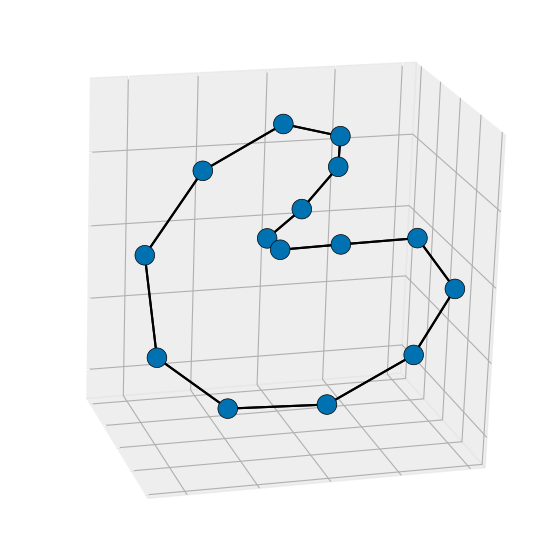

In [7]:
%matplotlib inline
# %matplotlib widget

cycle_v1_raw_elev = -64
cycle_v1_raw_azim = -130
cycle_v1_raw_roll = 41

# Styled plotting constants for this block
cycle_v1_styled_view = {"elev": cycle_v1_raw_elev, "azim": cycle_v1_raw_azim, "roll": cycle_v1_raw_roll}
cycle_v1_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v1_reduced_embeddings,
    cycle_v1_edge_list,
    title="",
    view=cycle_v1_styled_view,
    root_node_index=cycle_v1_root_node_index,
    axis_permutation=cycle_v1_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v1_context.args.graph_type}_{cycle_v1_context.args.model_architecture_label}_embedding_graph_geometric_selfEdges.pdf",
    save_context=cycle_v1_context,
);


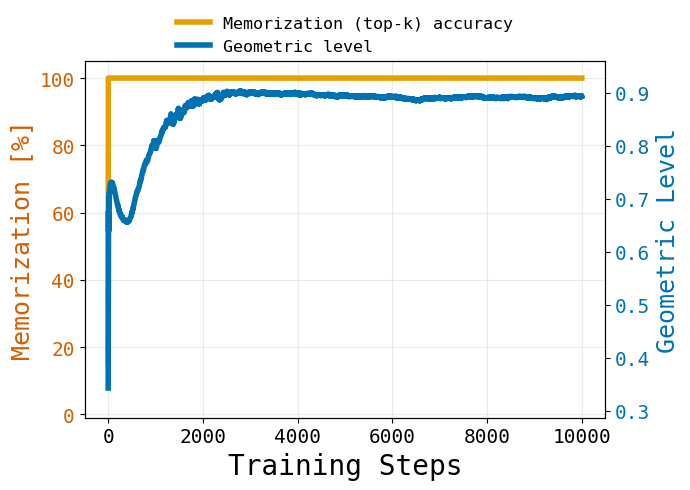

In [8]:
# Line-plot constants for this block
cycle_v1_line_plot_title = ""

cycle_v1_curve_steps, cycle_v1_curve_associative, cycle_v1_curve_geometric = compute_associative_geometric_curves(
    cycle_v1_embedding_history,
    cycle_v1_topk_recovery_history,
    cycle_v1_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v1_curve_steps,
    associative_scores=cycle_v1_curve_associative,
    geometric_scores=cycle_v1_curve_geometric,
    title=cycle_v1_line_plot_title,
    save_path=f"../saved_plots/regularization/{cycle_v1_context.args.graph_type}_{cycle_v1_context.args.model_architecture_label}_associative_geometric_curves_geometric_selfEdges.pdf",
    save_context=cycle_v1_context,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


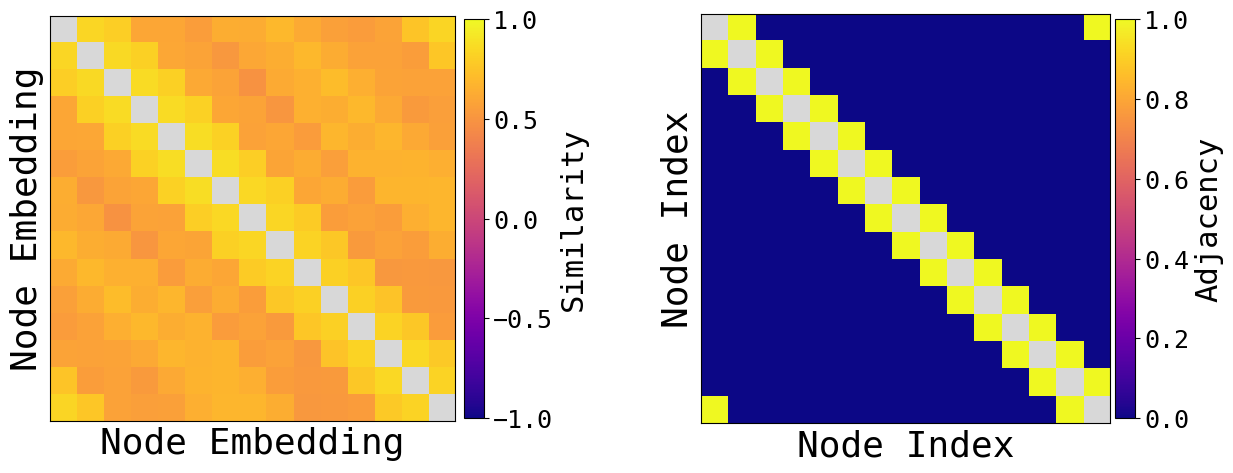

In [9]:
# Heatmap constants for this block
cycle_v1_heatmap_graph_type = cycle_v1_context.args.graph_type
cycle_v1_heatmap_epoch = -1
cycle_v1_heatmap_cmap_name = "plasma"
cycle_v1_heatmap_wspace = 0.5

cycle_v1_heatmap_embeddings, cycle_v1_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v1_embedding_history,
    fallback_embeddings=cycle_v1_node_embeddings,
    requested_step=cycle_v1_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v1_heatmap_resolved_epoch)
cycle_v1_heatmap_order = list(range(cycle_v1_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v1_heatmap_order), 4):
    row = cycle_v1_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v1_heatmap_embeddings,
    edge_list=cycle_v1_edge_list,
    graph_type=cycle_v1_heatmap_graph_type,
    root_node_index=cycle_v1_root_node_index,
    custom_order=cycle_v1_heatmap_order,
    cmap_name=cycle_v1_heatmap_cmap_name,
    wspace=cycle_v1_heatmap_wspace,
    save_path=f"../saved_plots/regularization/{cycle_v1_context.args.graph_type}_{cycle_v1_context.args.model_architecture_label}_embedding_heatmap_geometric_selfEdges.pdf",
    save_context=cycle_v1_context,
);


### Skewed Low-Rank Spectral Bias


In [10]:
# Laplacian geometry constants for this block
cycle_v1_laplacian_axis_indices = (-2, -3, -4)
cycle_v1_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v1_edge_list,
    node_count=cycle_v1_node_embeddings.shape[0],
)

cycle v3 normalized eigenvalues:
 [ 1.     1.     0.827  0.827  0.572  0.572  0.28   0.28   0.    -0.
 -0.219 -0.219 -0.338 -0.338]
Tiny cycle (V3) | edge_margin_original: 7.404389
Tiny cycle (V3) | edge_margin_skewed: 6.882059
Tiny cycle (V3) | edge_top1_accuracy_skewed: 80.00%


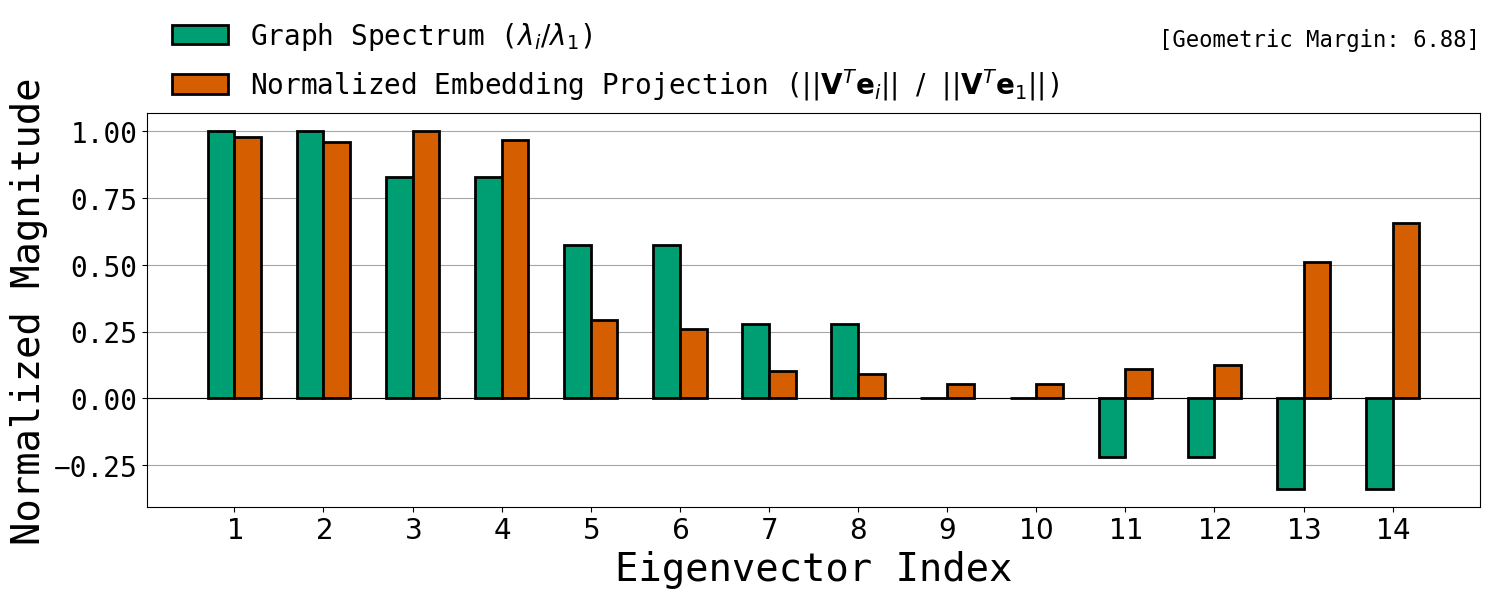

In [11]:
# Spectral-bias constants for this block
cycle_v1_spectral_drop_top_eigenvector = True
cycle_v1_spectral_reorder_prefix = None
cycle_v1_spectral_cutoff = None
cycle_v1_spectral_figsize = (15.0, 6.0)
cycle_v1_spectral_legend_anchor = (0.0, 1.3)

cycle_v1_norm_eigenvalues, cycle_v1_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v1_node_embeddings,
    spectral_state=cycle_v1_spectral_state,
    drop_top_eigenvector=cycle_v1_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v1_spectral_reorder_prefix,
)

print("cycle v3 normalized eigenvalues:\n", cycle_v1_norm_eigenvalues.round(3))

# Compute margin and accuracy
cycle_v1_margin_original, cycle_v1_margin_geometric, cycle_v1_accuracy_skewed = compute_margin_and_accuracy(
    cycle_v1_context.model,
    cycle_v1_edge_list,
    label="Tiny cycle (V3)",
)

plot_spectral_bias(
    norm_eigenvalues=cycle_v1_norm_eigenvalues,
    norm_projections=cycle_v1_norm_projections,
    title=f"[Geometric Margin: {cycle_v1_margin_geometric:.2f}]",
    cutoff=cycle_v1_spectral_cutoff,
    figsize=cycle_v1_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v1_spectral_legend_anchor,
    save=True,
    filename=f"../saved_plots/regularization/{cycle_v1_context.args.graph_type}_{cycle_v1_context.args.model_architecture_label}_eigen_projection_geometric_selfEdges.pdf",
    save_context=cycle_v1_context,
);

## 2a) Tiny cycle (No Weight Decay/Dropout -- Large LR) --> Geometric Setup


In [12]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_tiny_deep_sequence_model_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)
from tiny_graphs_notebooks.analysis.analysis_spectral import (
    compute_margin_and_accuracy,
)


In [13]:
cycle_v2a_seed = 7

cycle_v2a_train_from_scratch = True
cycle_v2a_checkpoint_path = ""
cycle_v2a_embedding_history_path = ""
cycle_v2a_topk_history_path = ""
cycle_v2a_dataset_overwrite = False

cycle_v2a_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.01,
    "--edge_memorization_epochs": 10000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 512,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": True,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [14]:
cycle_v2a_context = build_tiny_deep_sequence_model_context(
    cycle_v2a_cli_config,
    seed=cycle_v2a_seed,
    dataset_overwrite=cycle_v2a_dataset_overwrite,
)

cycle_v2a_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v2a_context,
    train_from_scratch=cycle_v2a_train_from_scratch,
    checkpoint_path=cycle_v2a_checkpoint_path,
)

print("Run name:", cycle_v2a_context.args.run_name)
print("Checkpoint:", cycle_v2a_resolved_checkpoint_path)
print("Pretrain file:", cycle_v2a_context.pretrain_path)
print("Train file:", cycle_v2a_context.train_path)
print("Test file:", cycle_v2a_context.test_path)
print("Archived checkpoint:", cycle_v2a_context.checkpoint_path)
print("Embedding history pickle:", cycle_v2a_context.embedding_history_path)
print("Top-k pickle:", cycle_v2a_context.topk_history_path)
print("Manifest:", cycle_v2a_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 50.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-181555/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-181555_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-181555
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p01x0_tl0-rev0-sd00-f

In [15]:
cycle_v2a_context.model

GPT(
  (lm_head): Linear(in_features=512, out_features=24, bias=False)
  (embed_tokens): Embedding(24, 512)
  (layers): ModuleList(
    (0): Block(
      (mlp): MLP_NeuralNet(
        (fc1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
)

In [16]:
cycle_v2a_eval_metrics = evaluate_edge_and_path(cycle_v2a_context)

print_evaluation_report("Tiny cycle (V1a)", cycle_v2a_eval_metrics)


Edge Memorization | Loss: 0.6977 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 148.52it/s]


Edge Memorization | Loss: 0.6977 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 78.13it/s]

Tiny cycle (V1a) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [17]:
cycle_v2a_node_embeddings, cycle_v2a_edge_list, cycle_v2a_root_node_index = collect_embeddings_and_edges(cycle_v2a_context)

cycle_v2a_embedding_history, cycle_v2a_topk_recovery_history = load_analysis_histories(
    cycle_v2a_context,
    cycle_v2a_edge_list,
    embedding_history_path=cycle_v2a_embedding_history_path,
    topk_history_path=cycle_v2a_topk_history_path,
)

if not cycle_v2a_embedding_history:
    cycle_v2a_embedding_history = {0: cycle_v2a_node_embeddings}
if not cycle_v2a_topk_recovery_history:
    cycle_v2a_topk_recovery_history = {0: cycle_v2a_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v2a_node_embeddings.shape)
print("Number of edges:", len(cycle_v2a_edge_list))
print("Root node index:", cycle_v2a_root_node_index)
print("Embedding history steps:", len(cycle_v2a_embedding_history))
print("Top-k history steps:", len(cycle_v2a_topk_recovery_history))


Node embedding shape: (15, 512)
Number of edges: 30
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [18]:
# Reduction config for this block (kept local to reduction stage)
cycle_v2a_use_umap = False
cycle_v2a_reduction_dim = 5
cycle_v2a_umap_n_neighbors = 4
cycle_v2a_umap_min_dist = 0.3

cycle_v2a_reduced_full, cycle_v2a_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v2a_node_embeddings,
    use_umap=cycle_v2a_use_umap,
    reduction_dim=cycle_v2a_reduction_dim,
    seed=cycle_v2a_seed,
    umap_n_neighbors=cycle_v2a_umap_n_neighbors,
    umap_min_dist=cycle_v2a_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v2a_reduced_embeddings = cycle_v2a_reduced_full[:, :3]
print("Reduced full shape:", cycle_v2a_reduced_full.shape)
print("Reduced xyz shape:", cycle_v2a_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

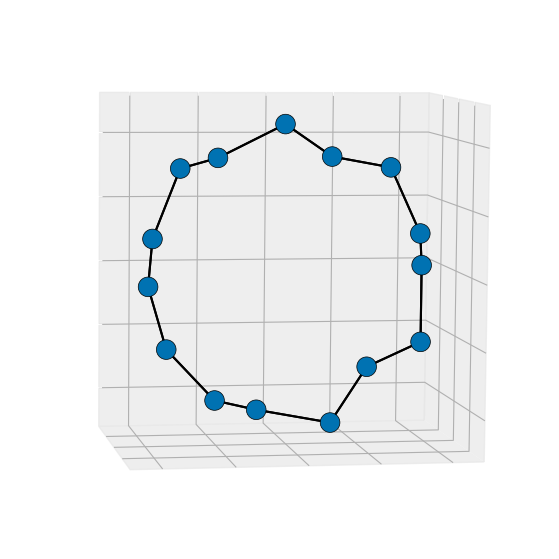

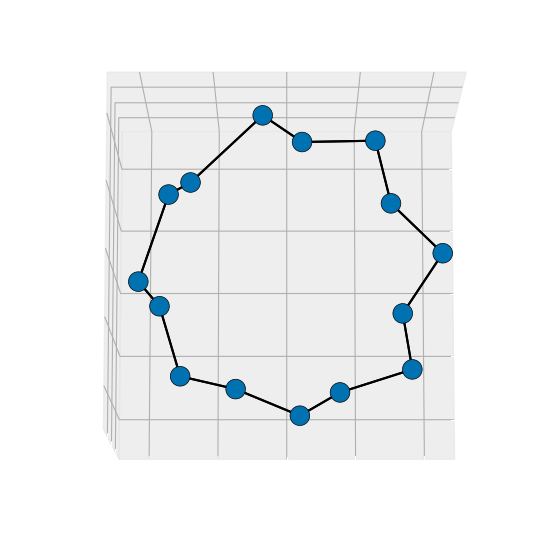

In [19]:
%matplotlib inline
# %matplotlib widget

cycle_v2a_raw_elev = 78
cycle_v2a_raw_azim = 59
cycle_v2a_raw_roll = -121

# Styled plotting constants for this block
cycle_v2a_styled_view = {"elev": cycle_v2a_raw_elev, "azim": cycle_v2a_raw_azim, "roll": cycle_v2a_raw_roll}
cycle_v2a_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v2a_reduced_embeddings,
    cycle_v2a_edge_list,
    title="",
    view=cycle_v2a_styled_view,
    root_node_index=cycle_v2a_root_node_index,
    axis_permutation=cycle_v2a_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v2a_context.args.graph_type}_{cycle_v2a_context.args.model_architecture_label}_embedding_graph_default_largeLR.pdf",
    save_context=cycle_v2a_context,
);

# ###############
# Another Angle
# ###############

cycle_v2a_raw_elev = 80
cycle_v2a_raw_azim = 0
cycle_v2a_raw_roll = 0

# Styled plotting constants for this block
cycle_v2a_styled_view = {"elev": cycle_v2a_raw_elev, "azim": cycle_v2a_raw_azim, "roll": cycle_v2a_raw_roll}
cycle_v2a_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v2a_reduced_embeddings,
    cycle_v2a_edge_list,
    title="",
    view=cycle_v2a_styled_view,
    root_node_index=cycle_v2a_root_node_index,
    axis_permutation=cycle_v2a_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v2a_context.args.graph_type}_{cycle_v2a_context.args.model_architecture_label}_embedding_graph_default_largeLR_alternate_view.pdf",
    save_context=cycle_v2a_context,
    alt_view=True,
);


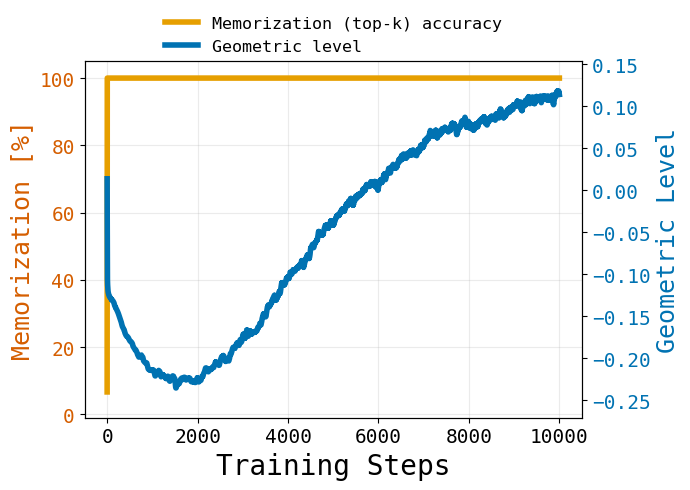

In [20]:
# Line-plot constants for this block
cycle_v2a_line_plot_title = ""

cycle_v2a_curve_steps, cycle_v2a_curve_associative, cycle_v2a_curve_geometric = compute_associative_geometric_curves(
    cycle_v2a_embedding_history,
    cycle_v2a_topk_recovery_history,
    cycle_v2a_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v2a_curve_steps,
    associative_scores=cycle_v2a_curve_associative,
    geometric_scores=cycle_v2a_curve_geometric,
    title=cycle_v2a_line_plot_title,
    save_path=f"../saved_plots/regularization/{cycle_v2a_context.args.graph_type}_{cycle_v2a_context.args.model_architecture_label}_associative_geometric_curves_default_largeLR.pdf",
    save_context=cycle_v2a_context,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


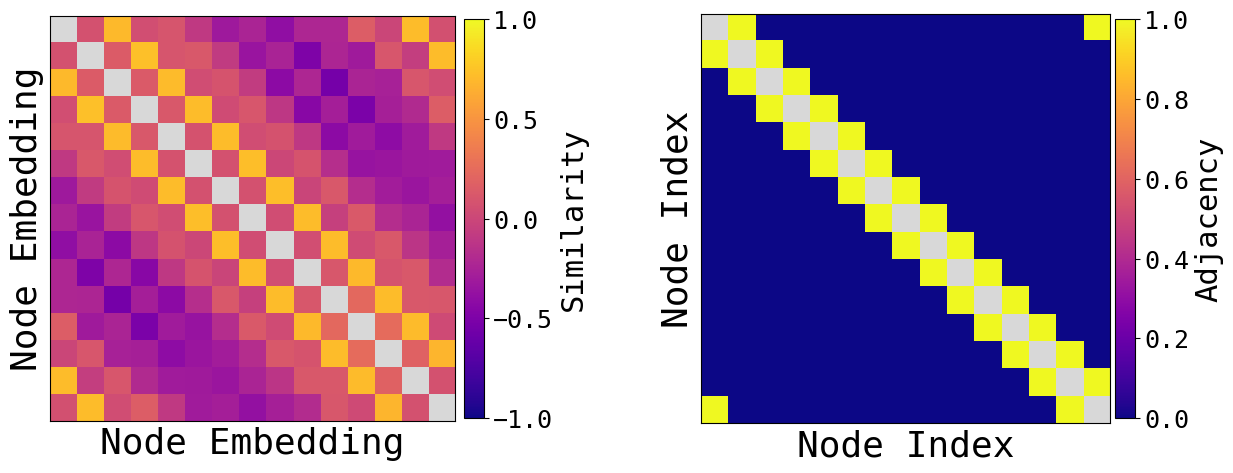

In [21]:
# Heatmap constants for this block
cycle_v2a_heatmap_graph_type = cycle_v2a_context.args.graph_type
cycle_v2a_heatmap_epoch = -1
cycle_v2a_heatmap_cmap_name = "plasma"
cycle_v2a_heatmap_wspace = 0.5

cycle_v2a_heatmap_embeddings, cycle_v2a_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v2a_embedding_history,
    fallback_embeddings=cycle_v2a_node_embeddings,
    requested_step=cycle_v2a_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v2a_heatmap_resolved_epoch)
cycle_v2a_heatmap_order = list(range(cycle_v2a_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v2a_heatmap_order), 4):
    row = cycle_v2a_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v2a_heatmap_embeddings,
    edge_list=cycle_v2a_edge_list,
    graph_type=cycle_v2a_heatmap_graph_type,
    root_node_index=cycle_v2a_root_node_index,
    custom_order=cycle_v2a_heatmap_order,
    cmap_name=cycle_v2a_heatmap_cmap_name,
    wspace=cycle_v2a_heatmap_wspace,
    save_path=f"../saved_plots/regularization/{cycle_v2a_context.args.graph_type}_{cycle_v2a_context.args.model_architecture_label}_embedding_heatmap_default_largeLR.pdf",
    save_context=cycle_v2a_context,
);


### Skewed Low-Rank Spectral Bias


In [22]:
# Laplacian geometry constants for this block
cycle_v2a_laplacian_axis_indices = (-2, -3, -4)
cycle_v2a_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v2a_edge_list,
    node_count=cycle_v2a_node_embeddings.shape[0],
)

cycle normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]
Tiny cycle (V1a) | edge_margin_original: 8.816553
Tiny cycle (V1a) | edge_margin_skewed: 7.870975
Tiny cycle (V1a) | edge_top1_accuracy_skewed: 100.00%


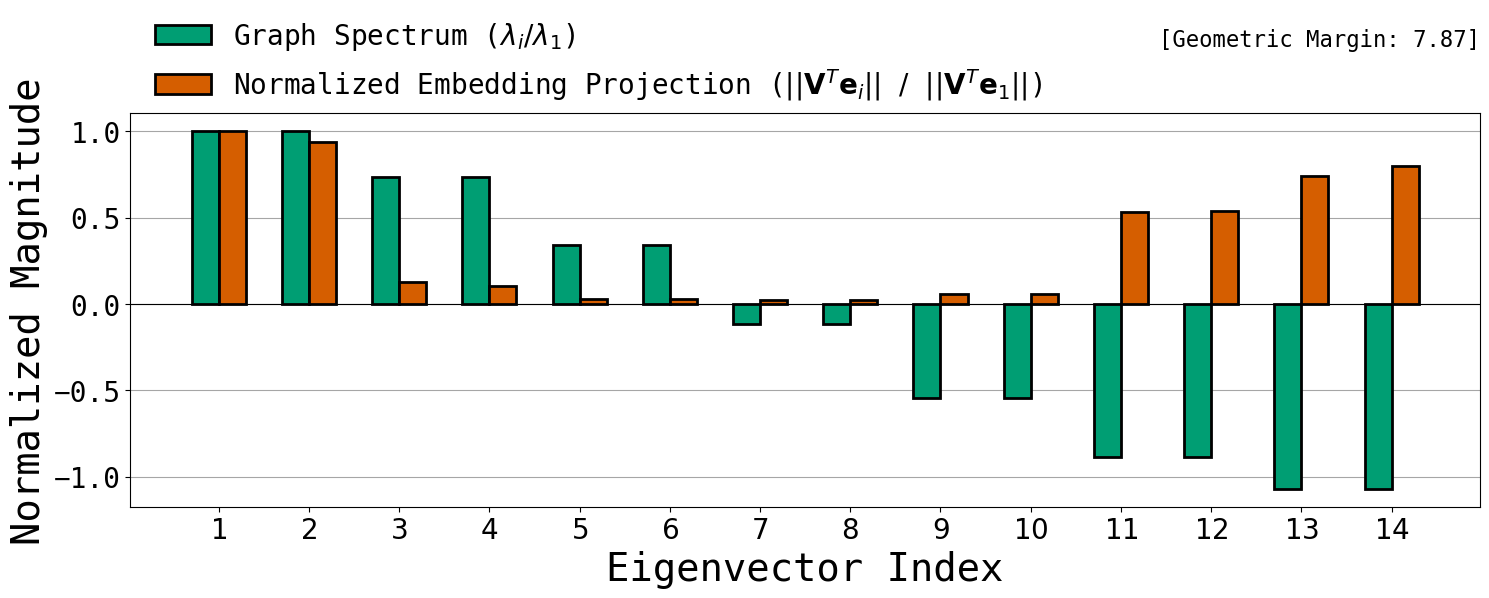

In [23]:
# Spectral-bias constants for this block
cycle_v2a_spectral_drop_top_eigenvector = True
cycle_v2a_spectral_reorder_prefix = None
cycle_v2a_spectral_cutoff = None
cycle_v2a_spectral_figsize = (15.0, 6.0)
cycle_v2a_spectral_legend_anchor = (0.0, 1.3)

cycle_v2a_norm_eigenvalues, cycle_v2a_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v2a_node_embeddings,
    spectral_state=cycle_v2a_spectral_state,
    drop_top_eigenvector=cycle_v2a_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v2a_spectral_reorder_prefix,
)

print("cycle normalized eigenvalues:\n", cycle_v2a_norm_eigenvalues.round(3))

# Compute margin and accuracy
cycle_v2a_margin_original, cycle_v2a_margin_geometric, cycle_v2a_accuracy_skewed = compute_margin_and_accuracy(
    cycle_v2a_context.model,
    cycle_v2a_edge_list,
    label="Tiny cycle (V1a)",
)

plot_spectral_bias(
    norm_eigenvalues=cycle_v2a_norm_eigenvalues,
    norm_projections=cycle_v2a_norm_projections,
    title=f"[Geometric Margin: {cycle_v2a_margin_geometric:.2f}]",
    cutoff=cycle_v2a_spectral_cutoff,
    figsize=cycle_v2a_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v2a_spectral_legend_anchor,
    save=True,
    filename=f"../saved_plots/regularization/{cycle_v2a_context.args.graph_type}_{cycle_v2a_context.args.model_architecture_label}_eigen_projection_default_largeLR.pdf",
    save_context=cycle_v2a_context,
);


## 2b) Tiny cycle (No Weight Decay/Dropout -- Small LR) --> Geometric Setup (Weakened)


In [24]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_tiny_deep_sequence_model_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)
from tiny_graphs_notebooks.analysis.analysis_spectral import (
    compute_margin_and_accuracy,
)


In [25]:
cycle_v2b_seed = 7

cycle_v2b_train_from_scratch = True
cycle_v2b_checkpoint_path = ""
cycle_v2b_embedding_history_path = ""
cycle_v2b_topk_history_path = ""
cycle_v2b_dataset_overwrite = False

cycle_v2b_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.0001, #0.001,
    "--edge_memorization_epochs": 10000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 512,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": True,
    "--dropout_rate": 0., # NO DROPOUT
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,
}


In [26]:
cycle_v2b_context = build_tiny_deep_sequence_model_context(
    cycle_v2b_cli_config,
    seed=cycle_v2b_seed,
    dataset_overwrite=cycle_v2b_dataset_overwrite,
)

cycle_v2b_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v2b_context,
    train_from_scratch=cycle_v2b_train_from_scratch,
    checkpoint_path=cycle_v2b_checkpoint_path,
)

print("Run name:", cycle_v2b_context.args.run_name)
print("Checkpoint:", cycle_v2b_resolved_checkpoint_path)
print("Pretrain file:", cycle_v2b_context.pretrain_path)
print("Train file:", cycle_v2b_context.train_path)
print("Test file:", cycle_v2b_context.test_path)
print("Archived checkpoint:", cycle_v2b_context.checkpoint_path)
print("Embedding history pickle:", cycle_v2b_context.embedding_history_path)
print("Top-k pickle:", cycle_v2b_context.topk_history_path)
print("Manifest:", cycle_v2b_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 50.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-181949/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-181949_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-181949
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev

In [27]:
cycle_v2b_context.model

GPT(
  (lm_head): Linear(in_features=512, out_features=24, bias=False)
  (embed_tokens): Embedding(24, 512)
  (layers): ModuleList(
    (0): Block(
      (mlp): MLP_NeuralNet(
        (fc1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
)

In [28]:
cycle_v2b_eval_metrics = evaluate_edge_and_path(cycle_v2b_context)

print_evaluation_report("Tiny cycle (V1)", cycle_v2b_eval_metrics)


Edge Memorization | Loss: 0.6914 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 155.98it/s]


Edge Memorization | Loss: 0.6914 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 152.14it/s]

Tiny cycle (V1) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [29]:
cycle_v2b_node_embeddings, cycle_v2b_edge_list, cycle_v2b_root_node_index = collect_embeddings_and_edges(cycle_v2b_context)

cycle_v2b_embedding_history, cycle_v2b_topk_recovery_history = load_analysis_histories(
    cycle_v2b_context,
    cycle_v2b_edge_list,
    embedding_history_path=cycle_v2b_embedding_history_path,
    topk_history_path=cycle_v2b_topk_history_path,
)

if not cycle_v2b_embedding_history:
    cycle_v2b_embedding_history = {0: cycle_v2b_node_embeddings}
if not cycle_v2b_topk_recovery_history:
    cycle_v2b_topk_recovery_history = {0: cycle_v2b_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v2b_node_embeddings.shape)
print("Number of edges:", len(cycle_v2b_edge_list))
print("Root node index:", cycle_v2b_root_node_index)
print("Embedding history steps:", len(cycle_v2b_embedding_history))
print("Top-k history steps:", len(cycle_v2b_topk_recovery_history))


Node embedding shape: (15, 512)
Number of edges: 30
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [30]:
# Reduction config for this block (kept local to reduction stage)
cycle_v2b_use_umap = False
cycle_v2b_reduction_dim = 5
cycle_v2b_umap_n_neighbors = 4
cycle_v2b_umap_min_dist = 0.3

cycle_v2b_reduced_full, cycle_v2b_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v2b_node_embeddings,
    use_umap=cycle_v2b_use_umap,
    reduction_dim=cycle_v2b_reduction_dim,
    seed=cycle_v2b_seed,
    umap_n_neighbors=cycle_v2b_umap_n_neighbors,
    umap_min_dist=cycle_v2b_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v2b_reduced_embeddings = cycle_v2b_reduced_full[:, :3]
print("Reduced full shape:", cycle_v2b_reduced_full.shape)
print("Reduced xyz shape:", cycle_v2b_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

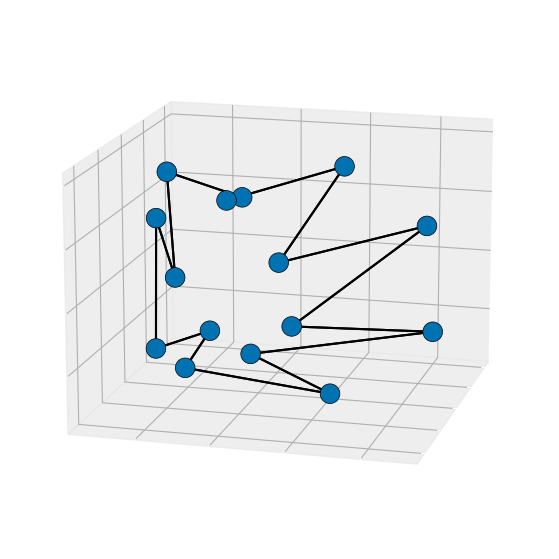

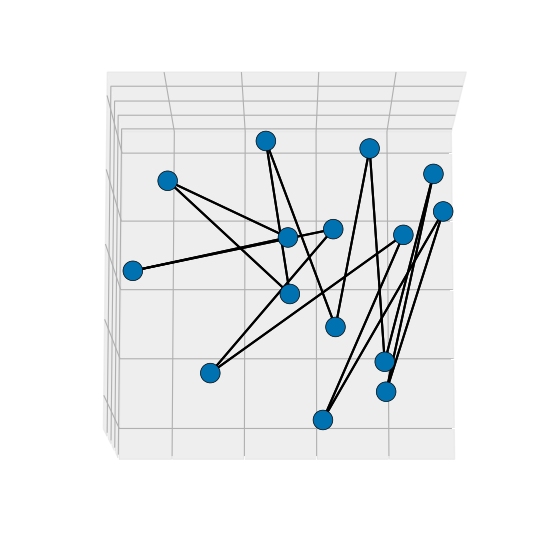

In [31]:
%matplotlib inline
# %matplotlib widget

cycle_v2b_raw_elev = -15
cycle_v2b_raw_azim = -15
cycle_v2b_raw_roll = 180

# Styled plotting constants for this block
cycle_v2b_styled_view = {"elev": cycle_v2b_raw_elev, "azim": cycle_v2b_raw_azim, "roll": cycle_v2b_raw_roll}
cycle_v2b_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v2b_reduced_embeddings,
    cycle_v2b_edge_list,
    title="",
    view=cycle_v2b_styled_view,
    root_node_index=cycle_v2b_root_node_index,
    axis_permutation=cycle_v2b_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v2b_context.args.graph_type}_{cycle_v2b_context.args.model_architecture_label}_embedding_graph_default_smallLR.pdf",
    save_context=cycle_v2b_context,
);

# ###############
# Another Angle
# ###############

cycle_v2b_raw_elev = 80
cycle_v2b_raw_azim = 0
cycle_v2b_raw_roll = 0

# Styled plotting constants for this block
cycle_v2b_styled_view = {"elev": cycle_v2b_raw_elev, "azim": cycle_v2b_raw_azim, "roll": cycle_v2b_raw_roll}
cycle_v2b_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v2b_reduced_embeddings,
    cycle_v2b_edge_list,
    title="",
    view=cycle_v2b_styled_view,
    root_node_index=cycle_v2b_root_node_index,
    axis_permutation=cycle_v2b_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v2b_context.args.graph_type}_{cycle_v2b_context.args.model_architecture_label}_embedding_graph_default_smallLR_alternate_view.pdf",
    save_context=cycle_v2b_context,
    alt_view=True,
);


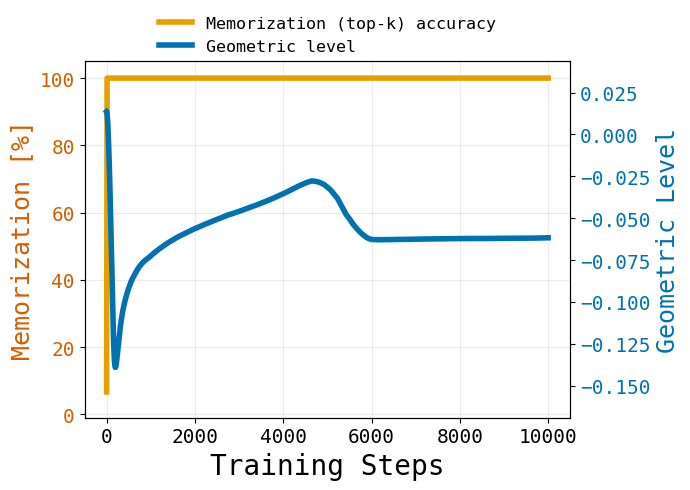

In [32]:
# Line-plot constants for this block
cycle_v2b_line_plot_title = ""

cycle_v2b_curve_steps, cycle_v2b_curve_associative, cycle_v2b_curve_geometric = compute_associative_geometric_curves(
    cycle_v2b_embedding_history,
    cycle_v2b_topk_recovery_history,
    cycle_v2b_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v2b_curve_steps,
    associative_scores=cycle_v2b_curve_associative,
    geometric_scores=cycle_v2b_curve_geometric,
    title=cycle_v2b_line_plot_title,
    save_path=f"../saved_plots/regularization/{cycle_v2b_context.args.graph_type}_{cycle_v2b_context.args.model_architecture_label}_associative_geometric_curves_default_smallLR.pdf",
    save_context=cycle_v2b_context,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


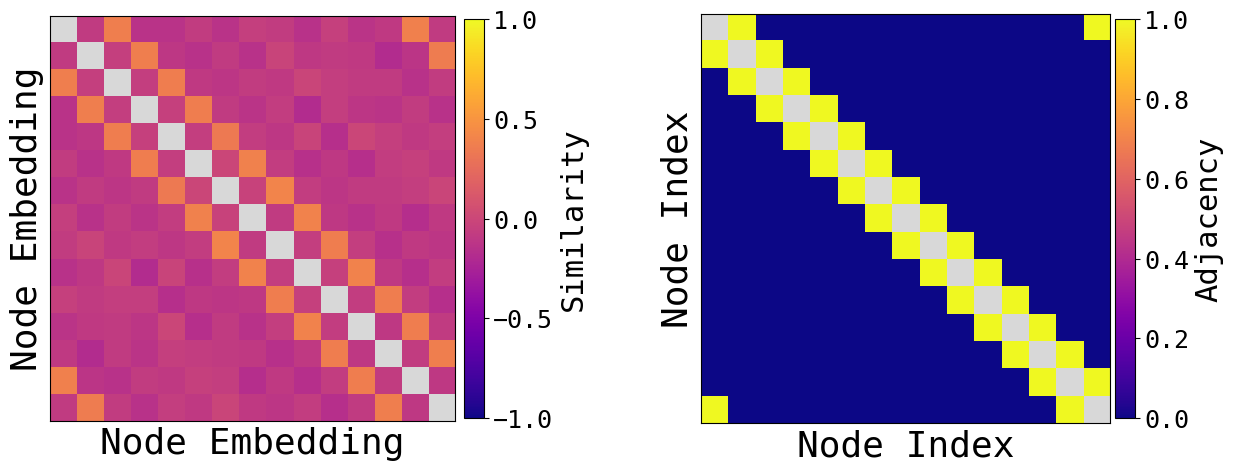

In [33]:
# Heatmap constants for this block
cycle_v2b_heatmap_graph_type = cycle_v2b_context.args.graph_type
cycle_v2b_heatmap_epoch = -1
cycle_v2b_heatmap_cmap_name = "plasma"
cycle_v2b_heatmap_wspace = 0.5

cycle_v2b_heatmap_embeddings, cycle_v2b_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v2b_embedding_history,
    fallback_embeddings=cycle_v2b_node_embeddings,
    requested_step=cycle_v2b_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v2b_heatmap_resolved_epoch)
cycle_v2b_heatmap_order = list(range(cycle_v2b_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v2b_heatmap_order), 4):
    row = cycle_v2b_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v2b_heatmap_embeddings,
    edge_list=cycle_v2b_edge_list,
    graph_type=cycle_v2b_heatmap_graph_type,
    root_node_index=cycle_v2b_root_node_index,
    custom_order=cycle_v2b_heatmap_order,
    cmap_name=cycle_v2b_heatmap_cmap_name,
    wspace=cycle_v2b_heatmap_wspace,
    save_path=f"../saved_plots/regularization/{cycle_v2b_context.args.graph_type}_{cycle_v2b_context.args.model_architecture_label}_embedding_heatmap_default_smallLR.pdf",
    save_context=cycle_v2b_context,
);


### Skewed Low-Rank Spectral Bias


In [34]:
# Laplacian geometry constants for this block
cycle_v2b_laplacian_axis_indices = (-2, -3, -4)
cycle_v2b_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v2b_edge_list,
    node_count=cycle_v2b_node_embeddings.shape[0],
)

cycle normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]
Tiny cycle (V1) | edge_margin_original: 15.459982
Tiny cycle (V1) | edge_margin_skewed: 3.416040
Tiny cycle (V1) | edge_top1_accuracy_skewed: 93.33%


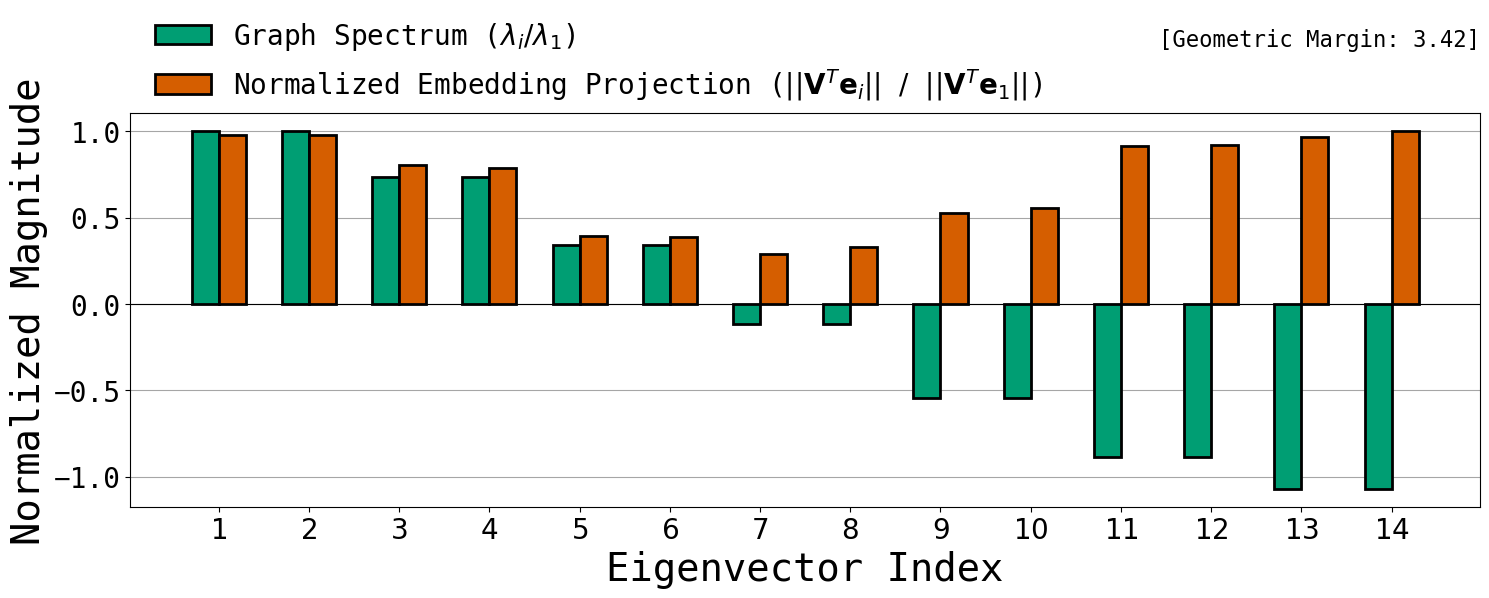

In [35]:
# Spectral-bias constants for this block
cycle_v2b_spectral_drop_top_eigenvector = True
cycle_v2b_spectral_reorder_prefix = None
cycle_v2b_spectral_cutoff = None
cycle_v2b_spectral_figsize = (15.0, 6.0)
cycle_v2b_spectral_legend_anchor = (0.0, 1.3)

cycle_v2b_norm_eigenvalues, cycle_v2b_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v2b_node_embeddings,
    spectral_state=cycle_v2b_spectral_state,
    drop_top_eigenvector=cycle_v2b_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v2b_spectral_reorder_prefix,
)

print("cycle normalized eigenvalues:\n", cycle_v2b_norm_eigenvalues.round(3))

# Compute margin and accuracy
cycle_v2b_margin_original, cycle_v2b_margin_geometric, cycle_v2b_accuracy_skewed = compute_margin_and_accuracy(
    cycle_v2b_context.model,
    cycle_v2b_edge_list,
    label="Tiny cycle (V1)",
)

plot_spectral_bias(
    norm_eigenvalues=cycle_v2b_norm_eigenvalues,
    norm_projections=cycle_v2b_norm_projections,
    title=f"[Geometric Margin: {cycle_v2b_margin_geometric:.2f}]",
    cutoff=cycle_v2b_spectral_cutoff,
    figsize=cycle_v2b_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v2b_spectral_legend_anchor,
    save=True,
    filename=f"../saved_plots/regularization/{cycle_v2b_context.args.graph_type}_{cycle_v2b_context.args.model_architecture_label}_eigen_projection_default_smallLR.pdf",
    save_context=cycle_v2b_context,
);


## 3a) Tiny cycle (Different Weight Init) --> non-geometric edge-memorization


In [36]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_tiny_deep_sequence_model_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)
from tiny_graphs_notebooks.analysis.analysis_spectral import (
    compute_margin_and_accuracy,
)

In [37]:
cycle_v3a_seed = 7

cycle_v3a_train_from_scratch = True
cycle_v3a_checkpoint_path = ""
cycle_v3a_embedding_history_path = ""
cycle_v3a_topk_history_path = ""
cycle_v3a_dataset_overwrite = False

cycle_v3a_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.0001,
    "--edge_memorization_epochs": 10000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 512, #100,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": True,
    "--dropout_rate": 0., # NO DROPOUT,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15, #10,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,

    "--weight_init_mode": "non_geometric", # Different
}


In [38]:
cycle_v3a_context = build_tiny_deep_sequence_model_context(
    cycle_v3a_cli_config,
    seed=cycle_v3a_seed,
    dataset_overwrite=cycle_v3a_dataset_overwrite,
)

Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

In [39]:
cycle_v3a_context.model

GPT(
  (lm_head): Linear(in_features=512, out_features=24, bias=False)
  (embed_tokens): Embedding(24, 512)
  (layers): ModuleList(
    (0): Block(
      (mlp): MLP_NeuralNet(
        (fc1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
)

In [40]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3a_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 110.614120
layers.0.mlp.fc1.weight: 10.268974
layers.0.mlp.fc1.bias: 0.000000


In [41]:
cycle_v2_context = build_tiny_deep_sequence_model_context(
    cycle_v3a_cli_config,
    seed=cycle_v3a_seed,
    dataset_overwrite=cycle_v3a_dataset_overwrite,
)

cycle_v3a_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v3a_context,
    train_from_scratch=cycle_v3a_train_from_scratch,
    checkpoint_path=cycle_v3a_checkpoint_path,
)

print("Run name:", cycle_v3a_context.args.run_name)
print("Checkpoint:", cycle_v3a_resolved_checkpoint_path)
print("Pretrain file:", cycle_v3a_context.pretrain_path)
print("Train file:", cycle_v3a_context.train_path)
print("Test file:", cycle_v3a_context.test_path)
print("Archived checkpoint:", cycle_v3a_context.checkpoint_path)
print("Embedding history pickle:", cycle_v3a_context.embedding_history_path)
print("Top-k pickle:", cycle_v3a_context.topk_history_path)
print("Manifest:", cycle_v3a_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 50.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182428/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182428_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182428
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev

In [42]:
cycle_v3a_eval_metrics = evaluate_edge_and_path(cycle_v3a_context)

print_evaluation_report("Tiny cycle (V3a)", cycle_v3a_eval_metrics)


Edge Memorization | Loss: 0.7046 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 129.73it/s]


Edge Memorization | Loss: 0.7046 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 61.52it/s]

Tiny cycle (V3a) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [43]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3a_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 110.472908
layers.0.mlp.fc1.weight: 10.274548
layers.0.mlp.fc1.bias: 0.027431


In [44]:
cycle_v3a_node_embeddings, cycle_v3a_edge_list, cycle_v3a_root_node_index = collect_embeddings_and_edges(cycle_v3a_context)

cycle_v3a_embedding_history, cycle_v3a_topk_recovery_history = load_analysis_histories(
    cycle_v3a_context,
    cycle_v3a_edge_list,
    embedding_history_path=cycle_v3a_embedding_history_path,
    topk_history_path=cycle_v3a_topk_history_path,
)

if not cycle_v3a_embedding_history:
    cycle_v3a_embedding_history = {0: cycle_v3a_node_embeddings}
if not cycle_v3a_topk_recovery_history:
    cycle_v3a_topk_recovery_history = {0: cycle_v3a_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v3a_node_embeddings.shape)
print("Number of edges:", len(cycle_v3a_edge_list))
print("Root node index:", cycle_v3a_root_node_index)
print("Embedding history steps:", len(cycle_v3a_embedding_history))
print("Top-k history steps:", len(cycle_v3a_topk_recovery_history))


Node embedding shape: (15, 512)
Number of edges: 30
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [45]:
# Reduction config for this block (kept local to reduction stage)
cycle_v3a_use_umap = False
cycle_v3a_reduction_dim = 5
cycle_v3a_umap_n_neighbors = 4
cycle_v3a_umap_min_dist = 0.3

cycle_v3a_reduced_full, cycle_v3a_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v3a_node_embeddings,
    use_umap=cycle_v3a_use_umap,
    reduction_dim=cycle_v3a_reduction_dim,
    seed=cycle_v3a_seed,
    umap_n_neighbors=cycle_v3a_umap_n_neighbors,
    umap_min_dist=cycle_v3a_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v3a_reduced_embeddings = cycle_v3a_reduced_full[:, :3]
print("Reduced full shape:", cycle_v3a_reduced_full.shape)
print("Reduced xyz shape:", cycle_v3a_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

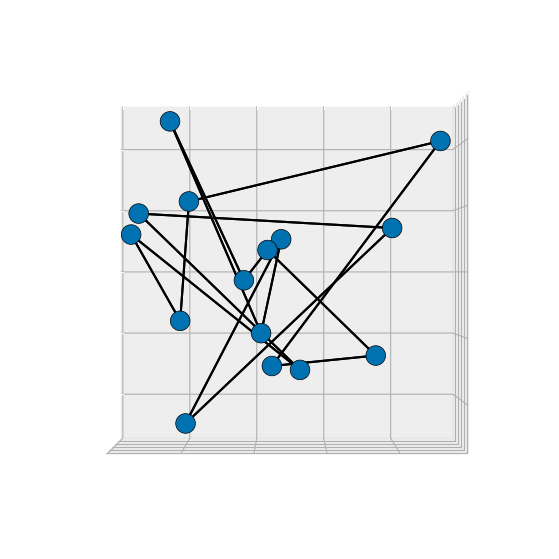

In [46]:
%matplotlib inline
# %matplotlib widget

cycle_v3a_raw_elev = 90
cycle_v3a_raw_azim = 0
cycle_v3a_raw_roll = 0

# Styled plotting constants for this block
cycle_v3a_styled_view = {"elev": cycle_v3a_raw_elev, "azim": cycle_v3a_raw_azim, "roll": cycle_v3a_raw_roll}
cycle_v3a_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v3a_reduced_embeddings,
    cycle_v3a_edge_list,
    title="",
    view=cycle_v3a_styled_view,
    root_node_index=cycle_v3a_root_node_index,
    axis_permutation=cycle_v3a_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v3a_context.args.graph_type}_{cycle_v3a_context.args.model_architecture_label}_embedding_graph_non_geometric.pdf",
    save_context=cycle_v3a_context,
);



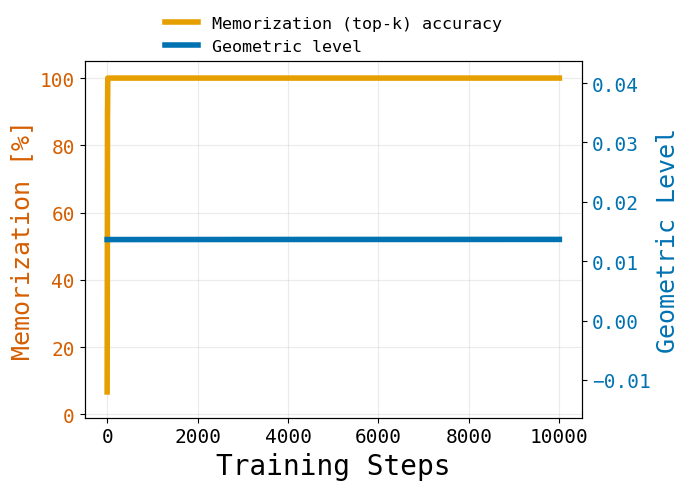

In [47]:
# Line-plot constants for this block
cycle_v3a_line_plot_title = ""

cycle_v3a_curve_steps, cycle_v3a_curve_associative, cycle_v3a_curve_geometric = compute_associative_geometric_curves(
    cycle_v3a_embedding_history,
    cycle_v3a_topk_recovery_history,
    cycle_v3a_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v3a_curve_steps,
    associative_scores=cycle_v3a_curve_associative,
    geometric_scores=cycle_v3a_curve_geometric,
    title=cycle_v3a_line_plot_title,
    save_path=f"../saved_plots/regularization/{cycle_v3a_context.args.graph_type}_{cycle_v3a_context.args.model_architecture_label}_associative_geometric_curves_non_geometric.pdf",
    save_context=cycle_v3a_context,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


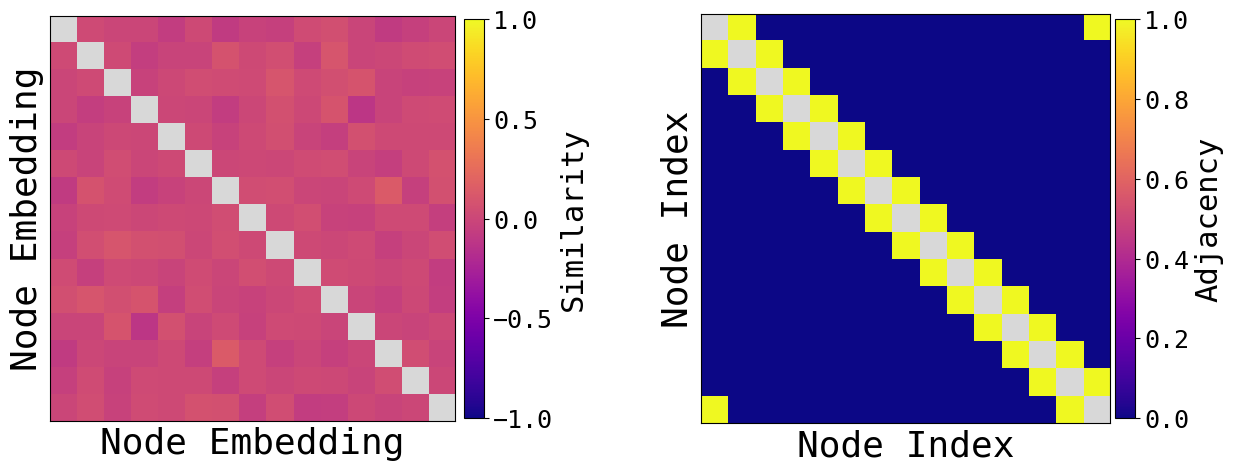

In [48]:
# Heatmap constants for this block
cycle_v3a_heatmap_graph_type = cycle_v3a_context.args.graph_type
cycle_v3a_heatmap_epoch = -1
cycle_v3a_heatmap_cmap_name = "plasma"
cycle_v3a_heatmap_wspace = 0.5

cycle_v3a_heatmap_embeddings, cycle_v3a_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v3a_embedding_history,
    fallback_embeddings=cycle_v3a_node_embeddings,
    requested_step=cycle_v3a_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v3a_heatmap_resolved_epoch)
cycle_v3a_heatmap_order = list(range(cycle_v3a_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v3a_heatmap_order), 4):
    row = cycle_v3a_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v3a_heatmap_embeddings,
    edge_list=cycle_v3a_edge_list,
    graph_type=cycle_v3a_heatmap_graph_type,
    root_node_index=cycle_v3a_root_node_index,
    custom_order=cycle_v3a_heatmap_order,
    cmap_name=cycle_v3a_heatmap_cmap_name,
    wspace=cycle_v3a_heatmap_wspace,
    save_path=f"../saved_plots/regularization/{cycle_v3a_context.args.graph_type}_{cycle_v3a_context.args.model_architecture_label}_embedding_heatmap_non_geometric.pdf",
    save_context=cycle_v3a_context,
);


### Skewed Low-Rank Spectral Bias


In [49]:
# Laplacian geometry constants for this block
cycle_v3a_laplacian_axis_indices = (-2, -3, -4)
cycle_v3a_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v3a_edge_list,
    node_count=cycle_v3a_node_embeddings.shape[0],
)

cycle v3a normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]
Tiny cycle (V3a) | edge_margin_original: 1.788370
Tiny cycle (V3a) | edge_margin_skewed: -0.748824
Tiny cycle (V3a) | edge_top1_accuracy_skewed: 33.33%


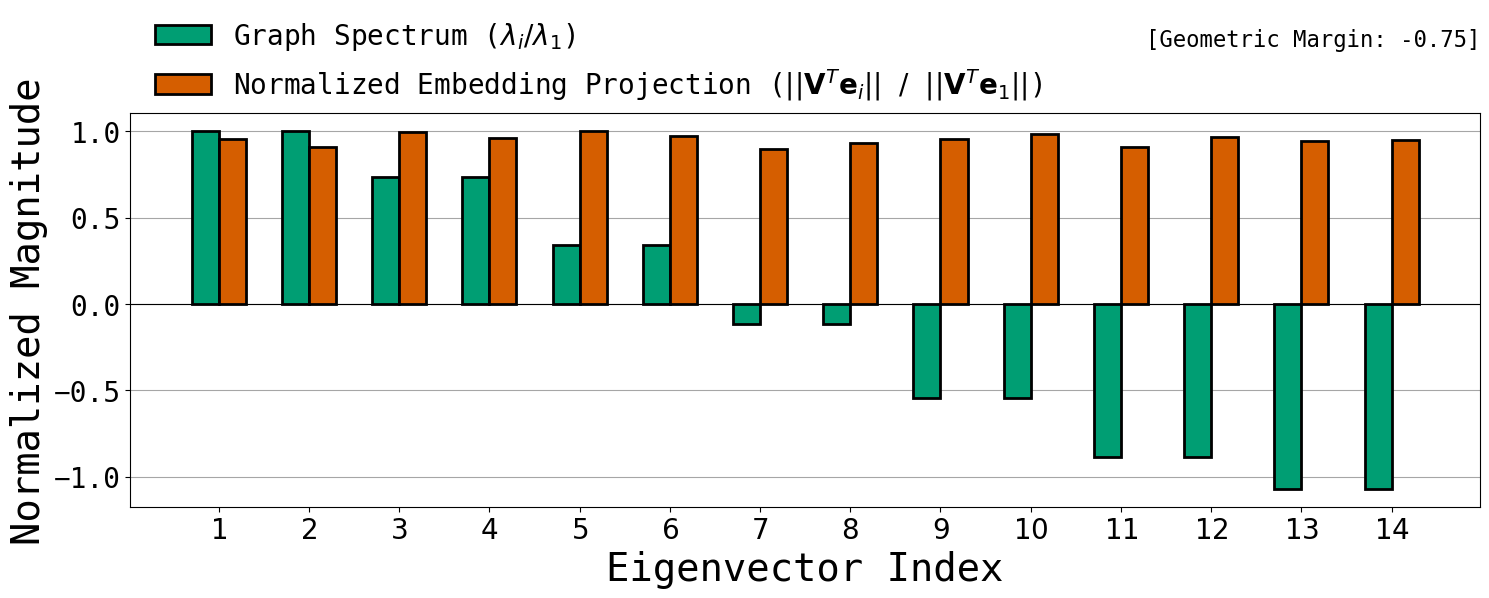

In [50]:
# Spectral-bias constants for this block
cycle_v3a_spectral_drop_top_eigenvector = True
cycle_v3a_spectral_reorder_prefix = None
cycle_v3a_spectral_cutoff = None
cycle_v3a_spectral_figsize = (15.0, 6.0)
cycle_v3a_spectral_legend_anchor = (0.0, 1.3)

cycle_v3a_norm_eigenvalues, cycle_v3a_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v3a_node_embeddings,
    spectral_state=cycle_v3a_spectral_state,
    drop_top_eigenvector=cycle_v3a_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v3a_spectral_reorder_prefix,
)

print("cycle v3a normalized eigenvalues:\n", cycle_v3a_norm_eigenvalues.round(3))

# Compute margin and accuracy
cycle_v3a_margin_original, cycle_v3a_margin_geometric, cycle_v3a_accuracy_skewed = compute_margin_and_accuracy(
    cycle_v3a_context.model,
    cycle_v3a_edge_list,
    label="Tiny cycle (V3a)",
)

plot_spectral_bias(
    norm_eigenvalues=cycle_v3a_norm_eigenvalues,
    norm_projections=cycle_v3a_norm_projections,
    title=f"[Geometric Margin: {cycle_v3a_margin_geometric:.2f}]",
    cutoff=cycle_v3a_spectral_cutoff,
    figsize=cycle_v3a_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v3a_spectral_legend_anchor,
    save=True,
    filename=f"../saved_plots/regularization/{cycle_v3a_context.args.graph_type}_{cycle_v3a_context.args.model_architecture_label}_eigen_projection_non_geometric.pdf",
    save_context=cycle_v3a_context,
);

## 3b) Tiny cycle (Different Weight Init) + Large LR --> geometric edge-memorization

In [51]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_tiny_deep_sequence_model_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)
from tiny_graphs_notebooks.analysis.analysis_spectral import (
    compute_margin_and_accuracy,
)


In [52]:
cycle_v3b_seed = 7

cycle_v3b_train_from_scratch = True
cycle_v3b_checkpoint_path = ""
cycle_v3b_embedding_history_path = ""
cycle_v3b_topk_history_path = ""
cycle_v3b_dataset_overwrite = False

cycle_v3b_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.1, #0.0001,
    "--edge_memorization_epochs": 10000, #1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 512, #100,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": False,
    "--dropout_rate": 0., # NO DROPOUT,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15, #10,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,

    "--weight_init_mode": "non_geometric", # Different
}


In [53]:
cycle_v3b_context = build_tiny_deep_sequence_model_context(
    cycle_v3b_cli_config,
    seed=cycle_v3b_seed,
    dataset_overwrite=cycle_v3b_dataset_overwrite,
)

Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

In [54]:
cycle_v3b_context.model

GPT(
  (lm_head): Linear(in_features=512, out_features=24, bias=False)
  (embed_tokens): Embedding(24, 512)
  (layers): ModuleList(
    (0): Block(
      (mlp): MLP_NeuralNet(
        (fc1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
)

In [55]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3b_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 110.614120
layers.0.mlp.fc1.weight: 10.268974
layers.0.mlp.fc1.bias: 0.000000


In [56]:
cycle_v3b_context = build_tiny_deep_sequence_model_context(
    cycle_v3b_cli_config,
    seed=cycle_v3b_seed,
    dataset_overwrite=cycle_v3b_dataset_overwrite,
)

cycle_v3b_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v3b_context,
    train_from_scratch=cycle_v3b_train_from_scratch,
    checkpoint_path=cycle_v3b_checkpoint_path,
)

print("Run name:", cycle_v3b_context.args.run_name)
print("Checkpoint:", cycle_v3b_resolved_checkpoint_path)
print("Pretrain file:", cycle_v3b_context.pretrain_path)
print("Train file:", cycle_v3b_context.train_path)
print("Test file:", cycle_v3b_context.test_path)
print("Archived checkpoint:", cycle_v3b_context.checkpoint_path)
print("Embedding history pickle:", cycle_v3b_context.embedding_history_path)
print("Top-k pickle:", cycle_v3b_context.topk_history_path)
print("Manifest:", cycle_v3b_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 50.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p1x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182649/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p1x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182649_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p1x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182649
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p1x0_tl0-rev0-sd00-fb11-

In [57]:
cycle_v3b_eval_metrics = evaluate_edge_and_path(cycle_v3b_context)

print_evaluation_report("Tiny cycle (V2a)", cycle_v3b_eval_metrics)


Edge Memorization | Loss: 0.7607 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 92.67it/s]


Edge Memorization | Loss: 0.7607 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 88.57it/s]

Tiny cycle (V2a) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [58]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3b_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 182.613876
layers.0.mlp.fc1.weight: 373.515839
layers.0.mlp.fc1.bias: 125.817719


In [59]:
cycle_v3b_node_embeddings, cycle_v3b_edge_list, cycle_v3b_root_node_index = collect_embeddings_and_edges(cycle_v3b_context)

cycle_v3b_embedding_history, cycle_v3b_topk_recovery_history = load_analysis_histories(
    cycle_v3b_context,
    cycle_v3b_edge_list,
    embedding_history_path=cycle_v3b_embedding_history_path,
    topk_history_path=cycle_v3b_topk_history_path,
)

if not cycle_v3b_embedding_history:
    cycle_v3b_embedding_history = {0: cycle_v3b_node_embeddings}
if not cycle_v3b_topk_recovery_history:
    cycle_v3b_topk_recovery_history = {0: cycle_v3b_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v3b_node_embeddings.shape)
print("Number of edges:", len(cycle_v3b_edge_list))
print("Root node index:", cycle_v3b_root_node_index)
print("Embedding history steps:", len(cycle_v3b_embedding_history))
print("Top-k history steps:", len(cycle_v3b_topk_recovery_history))


Node embedding shape: (15, 512)
Number of edges: 30
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [60]:
# Reduction config for this block (kept local to reduction stage)
cycle_v3b_use_umap = False
cycle_v3b_reduction_dim = 5
cycle_v3b_umap_n_neighbors = 4
cycle_v3b_umap_min_dist = 0.3

cycle_v3b_reduced_full, cycle_v3b_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v3b_node_embeddings,
    use_umap=cycle_v3b_use_umap,
    reduction_dim=cycle_v3b_reduction_dim,
    seed=cycle_v3b_seed,
    umap_n_neighbors=cycle_v3b_umap_n_neighbors,
    umap_min_dist=cycle_v3b_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v3b_reduced_embeddings = cycle_v3b_reduced_full[:, :3]
print("Reduced full shape:", cycle_v3b_reduced_full.shape)
print("Reduced xyz shape:", cycle_v3b_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

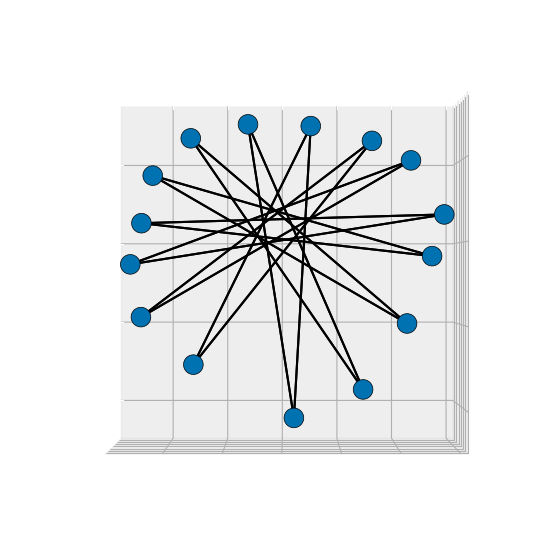

In [61]:
%matplotlib inline
# %matplotlib widget

cycle_v3b_raw_elev = 90
cycle_v3b_raw_azim = 0
cycle_v3b_raw_roll = 0

# Styled plotting constants for this block
cycle_v3b_styled_view = {"elev": cycle_v3b_raw_elev, "azim": cycle_v3b_raw_azim, "roll": cycle_v3b_raw_roll}
cycle_v3b_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v3b_reduced_embeddings,
    cycle_v3b_edge_list,
    title="",
    view=cycle_v3b_styled_view,
    root_node_index=cycle_v3b_root_node_index,
    axis_permutation=cycle_v3b_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v3b_context.args.graph_type}_{cycle_v3b_context.args.model_architecture_label}_embedding_graph_geometric_largeLR.pdf",
    save_context=cycle_v3b_context,
);


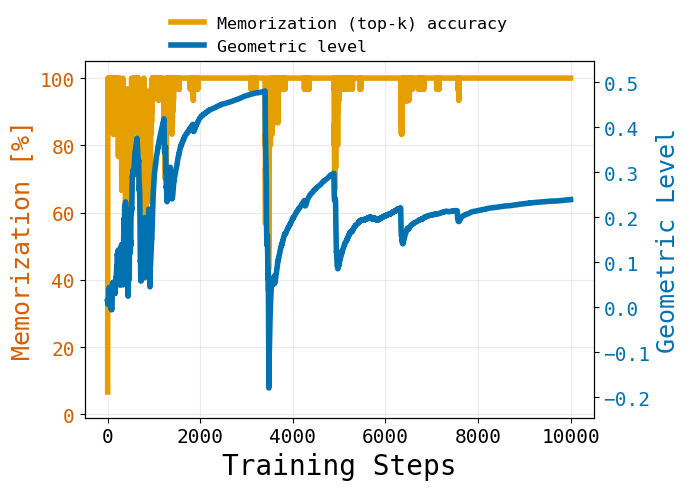

In [62]:
# Line-plot constants for this block
cycle_v3b_line_plot_title = ""

cycle_v3b_curve_steps, cycle_v3b_curve_associative, cycle_v3b_curve_geometric = compute_associative_geometric_curves(
    cycle_v3b_embedding_history,
    cycle_v3b_topk_recovery_history,
    cycle_v3b_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v3b_curve_steps,
    associative_scores=cycle_v3b_curve_associative,
    geometric_scores=cycle_v3b_curve_geometric,
    title=cycle_v3b_line_plot_title,
    save_path=f"../saved_plots/regularization/{cycle_v3b_context.args.graph_type}_{cycle_v3b_context.args.model_architecture_label}_associative_geometric_curves_geometric_largeLR.pdf",
    save_context=cycle_v3b_context,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


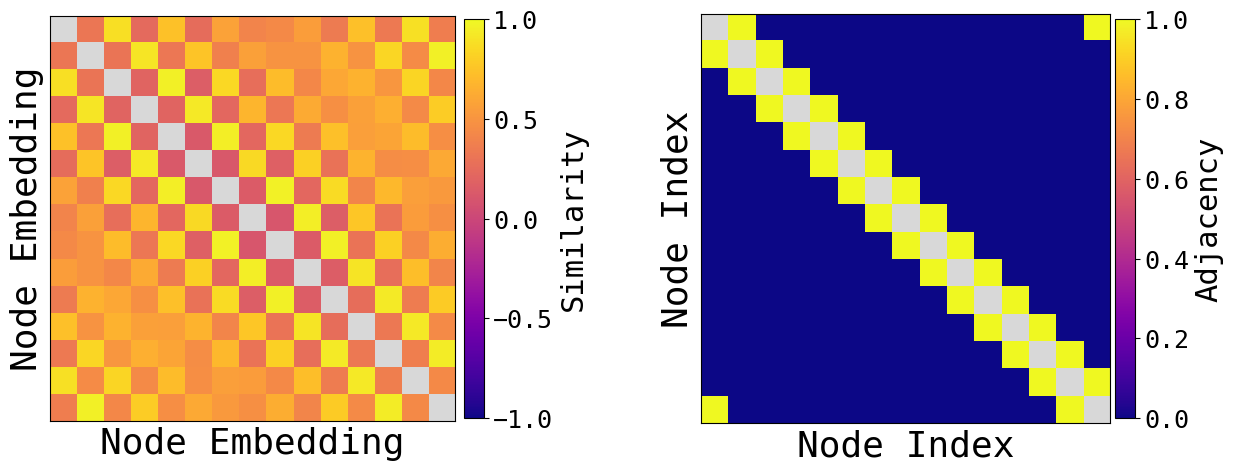

In [63]:
# Heatmap constants for this block
cycle_v3b_heatmap_graph_type = cycle_v3b_context.args.graph_type
cycle_v3b_heatmap_epoch = -1
cycle_v3b_heatmap_cmap_name = "plasma"
cycle_v3b_heatmap_wspace = 0.5

cycle_v3b_heatmap_embeddings, cycle_v3b_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v3b_embedding_history,
    fallback_embeddings=cycle_v3b_node_embeddings,
    requested_step=cycle_v3b_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v3b_heatmap_resolved_epoch)
cycle_v3b_heatmap_order = list(range(cycle_v3b_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v3b_heatmap_order), 4):
    row = cycle_v3b_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v3b_heatmap_embeddings,
    edge_list=cycle_v3b_edge_list,
    graph_type=cycle_v3b_heatmap_graph_type,
    root_node_index=cycle_v3b_root_node_index,
    custom_order=cycle_v3b_heatmap_order,
    cmap_name=cycle_v3b_heatmap_cmap_name,
    wspace=cycle_v3b_heatmap_wspace,
    save_path=f"../saved_plots/regularization/{cycle_v3b_context.args.graph_type}_{cycle_v3b_context.args.model_architecture_label}_embedding_heatmap_geometric_largeLR.pdf",
    save_context=cycle_v3b_context,
);


### Skewed Low-Rank Spectral Bias


In [64]:
# Laplacian geometry constants for this block
cycle_v3b_laplacian_axis_indices = (-2, -3, -4)
cycle_v3b_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v3b_edge_list,
    node_count=cycle_v3b_node_embeddings.shape[0],
)

cycle v2a normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]
Tiny cycle (V2a) | edge_margin_original: -58.318233
Tiny cycle (V2a) | edge_margin_skewed: 11.991537
Tiny cycle (V2a) | edge_top1_accuracy_skewed: 73.33%


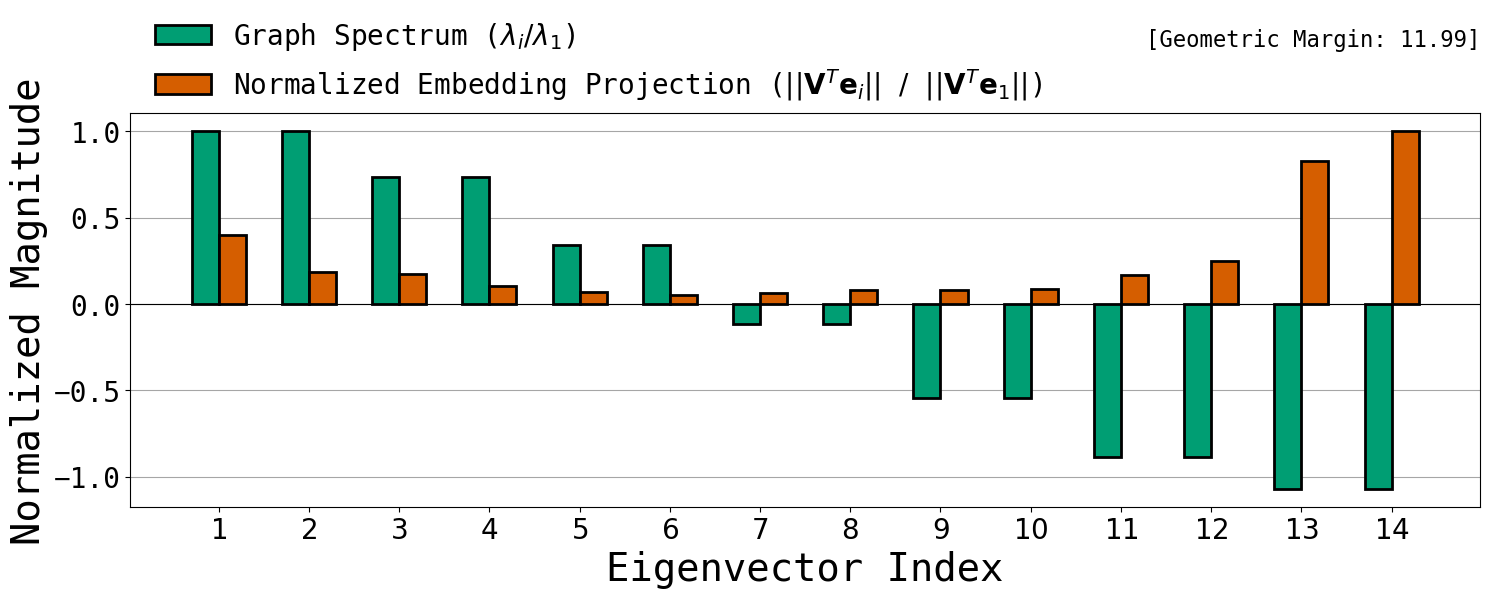

In [65]:
# Spectral-bias constants for this block
cycle_v3b_spectral_drop_top_eigenvector = True
cycle_v3b_spectral_reorder_prefix = None
cycle_v3b_spectral_cutoff = None
cycle_v3b_spectral_figsize = (15.0, 6.0)
cycle_v3b_spectral_legend_anchor = (0.0, 1.3)

cycle_v3b_norm_eigenvalues, cycle_v3b_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v3b_node_embeddings,
    spectral_state=cycle_v3b_spectral_state,
    drop_top_eigenvector=cycle_v3b_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v3b_spectral_reorder_prefix,
)

print("cycle v2a normalized eigenvalues:\n", cycle_v3b_norm_eigenvalues.round(3))

# Compute margin and accuracy
cycle_v3b_margin_original, cycle_v3b_margin_geometric, cycle_v3b_accuracy_skewed = compute_margin_and_accuracy(
    cycle_v3b_context.model,
    cycle_v3b_edge_list,
    label="Tiny cycle (V2a)",
)

plot_spectral_bias(
    norm_eigenvalues=cycle_v3b_norm_eigenvalues,
    norm_projections=cycle_v3b_norm_projections,
    title=f"[Geometric Margin: {cycle_v3b_margin_geometric:.2f}]",
    cutoff=cycle_v3b_spectral_cutoff,
    figsize=cycle_v3b_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v3b_spectral_legend_anchor,
    save=True,
    filename=f"../saved_plots/regularization/{cycle_v3b_context.args.graph_type}_{cycle_v3b_context.args.model_architecture_label}_eigen_projection_geometric_largeLR.pdf",
    save_context=cycle_v3b_context,
);

## 3c) Tiny cycle (Different Weight Init) + Weight Decay --> geometric edge-memorization


In [66]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_tiny_deep_sequence_model_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)
from tiny_graphs_notebooks.analysis.analysis_spectral import (
    compute_margin_and_accuracy,
)

In [67]:
cycle_v3c_seed = 7

cycle_v3c_train_from_scratch = True
cycle_v3c_checkpoint_path = ""
cycle_v3c_embedding_history_path = ""
cycle_v3c_topk_history_path = ""
cycle_v3c_dataset_overwrite = False

cycle_v3c_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.0001, #0.0001,
    "--edge_memorization_epochs": 10000, #1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 512, #100,
    "--optimizer_weight_decay": 10.0, 
    "--disable_edge_memorization_lr_decay": True,
    "--dropout_rate": 0., # NO DROPOUT,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15, #10,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,

    "--weight_init_mode": "non_geometric", # Different
}


In [68]:
cycle_v3c_context = build_tiny_deep_sequence_model_context(
    cycle_v3c_cli_config,
    seed=cycle_v3c_seed,
    dataset_overwrite=cycle_v3c_dataset_overwrite,
)

Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

In [69]:
cycle_v3c_context.model

GPT(
  (lm_head): Linear(in_features=512, out_features=24, bias=False)
  (embed_tokens): Embedding(24, 512)
  (layers): ModuleList(
    (0): Block(
      (mlp): MLP_NeuralNet(
        (fc1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
  )
)

In [70]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3c_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 110.614120
layers.0.mlp.fc1.weight: 10.268974
layers.0.mlp.fc1.bias: 0.000000


In [71]:
cycle_v3c_context = build_tiny_deep_sequence_model_context(
    cycle_v3c_cli_config,
    seed=cycle_v3c_seed,
    dataset_overwrite=cycle_v3c_dataset_overwrite,
)

cycle_v3c_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v3c_context,
    train_from_scratch=cycle_v3c_train_from_scratch,
    checkpoint_path=cycle_v3c_checkpoint_path,
)

print("Run name:", cycle_v3c_context.args.run_name)
print("Checkpoint:", cycle_v3c_resolved_checkpoint_path)
print("Pretrain file:", cycle_v3c_context.pretrain_path)
print("Train file:", cycle_v3c_context.train_path)
print("Test file:", cycle_v3c_context.test_path)
print("Archived checkpoint:", cycle_v3c_context.checkpoint_path)
print("Embedding history pickle:", cycle_v3c_context.embedding_history_path)
print("Top-k pickle:", cycle_v3c_context.topk_history_path)
print("Manifest:", cycle_v3c_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 50.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182920/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182920_edge_memorization_best.pt

Edge memorization complete. Best edge accuracy: 50.00%
Run name: in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-182920
Checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/saved_artifacts/checkpoints/cycle/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p0001x0_tl0-rev

In [72]:
cycle_v3c_eval_metrics = evaluate_edge_and_path(cycle_v3c_context)

print_evaluation_report("Tiny cycle (V4)", cycle_v3c_eval_metrics)


Edge Memorization | Loss: 0.7109 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 107.06it/s]


Edge Memorization | Loss: 0.7109 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 158.35it/s]

Tiny cycle (V4) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [73]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3c_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 7.548922
layers.0.mlp.fc1.weight: 7.263258
layers.0.mlp.fc1.bias: 0.943726


In [74]:
cycle_v3c_node_embeddings, cycle_v3c_edge_list, cycle_v3c_root_node_index = collect_embeddings_and_edges(cycle_v3c_context)

cycle_v3c_embedding_history, cycle_v3c_topk_recovery_history = load_analysis_histories(
    cycle_v3c_context,
    cycle_v3c_edge_list,
    embedding_history_path=cycle_v3c_embedding_history_path,
    topk_history_path=cycle_v3c_topk_history_path,
)

if not cycle_v3c_embedding_history:
    cycle_v3c_embedding_history = {0: cycle_v3c_node_embeddings}
if not cycle_v3c_topk_recovery_history:
    cycle_v3c_topk_recovery_history = {0: cycle_v3c_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v3c_node_embeddings.shape)
print("Number of edges:", len(cycle_v3c_edge_list))
print("Root node index:", cycle_v3c_root_node_index)
print("Embedding history steps:", len(cycle_v3c_embedding_history))
print("Top-k history steps:", len(cycle_v3c_topk_recovery_history))


Node embedding shape: (15, 512)
Number of edges: 30
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [75]:
# Reduction config for this block (kept local to reduction stage)
cycle_v3c_use_umap = False
cycle_v3c_reduction_dim = 5
cycle_v3c_umap_n_neighbors = 4
cycle_v3c_umap_min_dist = 0.3

cycle_v3c_reduced_full, cycle_v3c_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v3c_node_embeddings,
    use_umap=cycle_v3c_use_umap,
    reduction_dim=cycle_v3c_reduction_dim,
    seed=cycle_v3c_seed,
    umap_n_neighbors=cycle_v3c_umap_n_neighbors,
    umap_min_dist=cycle_v3c_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v3c_reduced_embeddings = cycle_v3c_reduced_full[:, :3]
print("Reduced full shape:", cycle_v3c_reduced_full.shape)
print("Reduced xyz shape:", cycle_v3c_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

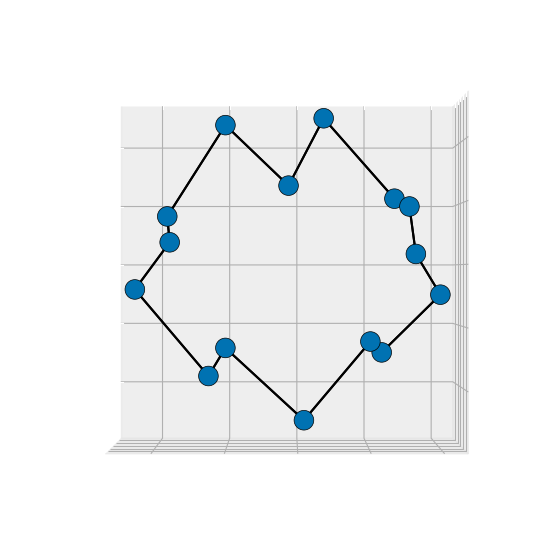

In [76]:
%matplotlib inline
# %matplotlib widget

cycle_v3c_raw_elev = 90
cycle_v3c_raw_azim = 0
cycle_v3c_raw_roll = 0

# Styled plotting constants for this block
cycle_v3c_styled_view = {"elev": cycle_v3c_raw_elev, "azim": cycle_v3c_raw_azim, "roll": cycle_v3c_raw_roll}
cycle_v3c_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v3c_reduced_embeddings,
    cycle_v3c_edge_list,
    title="",
    view=cycle_v3c_styled_view,
    root_node_index=cycle_v3c_root_node_index,
    axis_permutation=cycle_v3c_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v3c_context.args.graph_type}_{cycle_v3c_context.args.model_architecture_label}_embedding_graph_geometric_weightDecay.pdf",
    save_context=cycle_v3c_context,
);

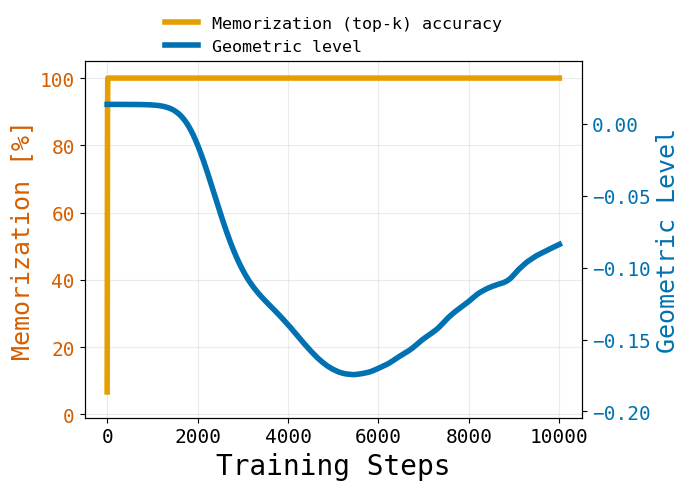

In [77]:
# Line-plot constants for this block
cycle_v3c_line_plot_title = ""

cycle_v3c_curve_steps, cycle_v3c_curve_associative, cycle_v3c_curve_geometric = compute_associative_geometric_curves(
    cycle_v3c_embedding_history,
    cycle_v3c_topk_recovery_history,
    cycle_v3c_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v3c_curve_steps,
    associative_scores=cycle_v3c_curve_associative,
    geometric_scores=cycle_v3c_curve_geometric,
    title=cycle_v3c_line_plot_title,
    save_path=f"../saved_plots/regularization/{cycle_v3c_context.args.graph_type}_{cycle_v3c_context.args.model_architecture_label}_associative_geometric_curves_geometric_weightDecay.pdf",
    save_context=cycle_v3c_context,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


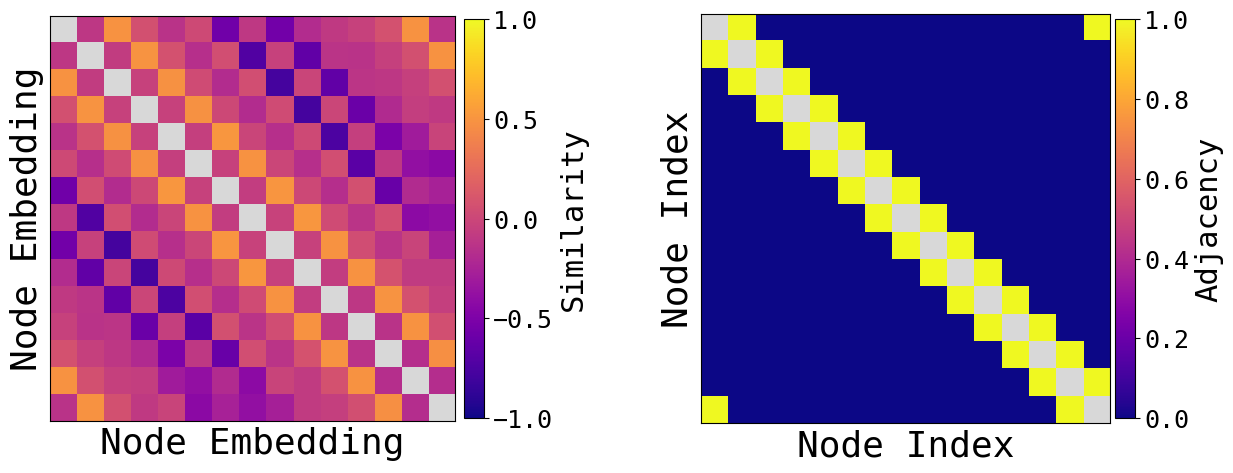

In [78]:
# Heatmap constants for this block
cycle_v3c_heatmap_graph_type = cycle_v3c_context.args.graph_type
cycle_v3c_heatmap_epoch = -1
cycle_v3c_heatmap_cmap_name = "plasma"
cycle_v3c_heatmap_wspace = 0.5

cycle_v3c_heatmap_embeddings, cycle_v3c_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v3c_embedding_history,
    fallback_embeddings=cycle_v3c_node_embeddings,
    requested_step=cycle_v3c_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v3c_heatmap_resolved_epoch)
cycle_v3c_heatmap_order = list(range(cycle_v3c_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v3c_heatmap_order), 4):
    row = cycle_v3c_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v3c_heatmap_embeddings,
    edge_list=cycle_v3c_edge_list,
    graph_type=cycle_v3c_heatmap_graph_type,
    root_node_index=cycle_v3c_root_node_index,
    custom_order=cycle_v3c_heatmap_order,
    cmap_name=cycle_v3c_heatmap_cmap_name,
    wspace=cycle_v3c_heatmap_wspace,
    save_path=f"../saved_plots/regularization/{cycle_v3c_context.args.graph_type}_{cycle_v3c_context.args.model_architecture_label}_embedding_heatmap_geometric_weightDecay.pdf",
    save_context=cycle_v3c_context,
);


### Skewed Low-Rank Spectral Bias


In [79]:
# Laplacian geometry constants for this block
cycle_v3c_laplacian_axis_indices = (-2, -3, -4)
cycle_v3c_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v3c_edge_list,
    node_count=cycle_v3c_node_embeddings.shape[0],
)

cycle v4 normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]
Tiny cycle (V4) | edge_margin_original: 4.801875
Tiny cycle (V4) | edge_margin_skewed: 2.967811
Tiny cycle (V4) | edge_top1_accuracy_skewed: 100.00%


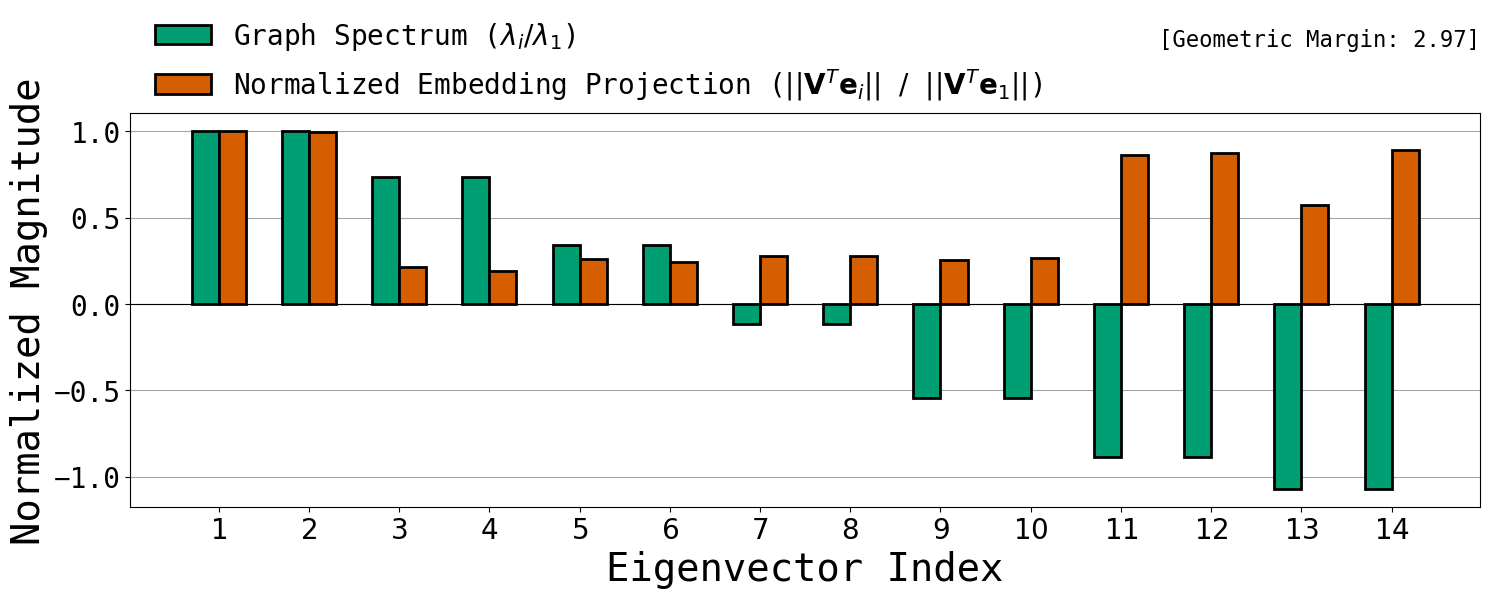

In [80]:
# Spectral-bias constants for this block
cycle_v3c_spectral_drop_top_eigenvector = True
cycle_v3c_spectral_reorder_prefix = None
cycle_v3c_spectral_cutoff = None
cycle_v3c_spectral_figsize = (15.0, 6.0)
cycle_v3c_spectral_legend_anchor = (0.0, 1.3)

cycle_v3c_norm_eigenvalues, cycle_v3c_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v3c_node_embeddings,
    spectral_state=cycle_v3c_spectral_state,
    drop_top_eigenvector=cycle_v3c_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v3c_spectral_reorder_prefix,
)

print("cycle v4 normalized eigenvalues:\n", cycle_v3c_norm_eigenvalues.round(3))

# Compute margin and accuracy
cycle_v3c_margin_original, cycle_v3c_margin_geometric, cycle_v3c_accuracy_skewed = compute_margin_and_accuracy(
    cycle_v3c_context.model,
    cycle_v3c_edge_list,
    label="Tiny cycle (V4)",
)

plot_spectral_bias(
    norm_eigenvalues=cycle_v3c_norm_eigenvalues,
    norm_projections=cycle_v3c_norm_projections,
    title=f"[Geometric Margin: {cycle_v3c_margin_geometric:.2f}]",
    cutoff=cycle_v3c_spectral_cutoff,
    figsize=cycle_v3c_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v3c_spectral_legend_anchor,
    save=True,
    filename=f"../saved_plots/regularization/{cycle_v3c_context.args.graph_type}_{cycle_v3c_context.args.model_architecture_label}_eigen_projection_geometric_weightDecay.pdf",
    save_context=cycle_v3c_context,
);

## 3d) Tiny cycle (Different Weight Init) + Dropout --> geometric edge-memorization

In [81]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (candidate for candidate in (CURRENT_DIR, *CURRENT_DIR.parents) if (candidate / "tiny_graphs_notebooks").is_dir()),
    CURRENT_DIR,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import matplotlib.pyplot as plt

from tiny_graphs_notebooks.notebook_utils.notebook_helpers import (
    build_tiny_deep_sequence_model_context,
    train_or_load_edge_model,
    evaluate_edge_and_path,
    collect_embeddings_and_edges,
    load_analysis_histories,
    print_evaluation_report,
)
from tiny_graphs_notebooks.analysis.analysis import (
    build_graph_spectral_state,
    compute_spectral_bias_from_state,
    plot_spectral_bias,
    build_reduced_evolution_snapshots,
    compute_associative_geometric_curves,
    get_star_branch_layout,
    plot_associative_vs_geometric_curves,
    plot_ordered_heatmaps,
    plot_stylized_embedding_graph,
    plot_three_snapshot_evolution,
    reduce_embeddings_for_plot,
    select_embedding_snapshot,
)
from tiny_graphs_notebooks.analysis.analysis_spectral import (
    compute_margin_and_accuracy,
)

In [82]:
cycle_v3d_seed = 7

cycle_v3d_train_from_scratch = True
cycle_v3d_checkpoint_path = ""
cycle_v3d_embedding_history_path = ""
cycle_v3d_topk_history_path = ""
cycle_v3d_dataset_overwrite = False

cycle_v3d_cli_config = {
    "--training_recipe": "staged_full_path",
    "--experiment_log_root": "./experiment_logs",
    "--dataset_root": "data/datasets/in_weights_graphs",
    "--dataset_name": "in_weights",
    "--track_embedding_evolution": True,
    "--track_top_k_predictions": True,

    "--edge_memorization_batch_size": 2048,
    "--edge_memorization_learning_rate": 0.001, #0.0001,
    "--edge_memorization_epochs": 10000, #1000,
    "--edge_memorization_warmup_steps": 0,

    "--path_finetuning_batch_size": 2048,
    "--path_finetuning_learning_rate": 0,
    "--path_finetuning_epochs": 0,
    "--path_finetuning_warmup_steps": 0,
    "--disable_path_finetuning_lr_decay": True,

    "--edge_memorization_eval_interval_epochs": 25,
    "--path_finetuning_eval_interval_epochs": 1,

    "--model_family": "gpt",
    "--transformer_layer_count": 1,
    "--attention_head_count": 1,
    "--embedding_dimension": 512, #100,
    "--optimizer_weight_decay": 0, # NO WEIGHT DECAY
    "--disable_edge_memorization_lr_decay": True,
    "--dropout_rate": 0.4,
    "--no-use_attention": True,
    "--no-use_residual_connections": True,
    "--no-use_layer_norm": True,
    "--use_mlp_only_blocks": True,
    "--no-use_positional_encoding": True,

    "--graph_type": "cycle",
    "--path_length": 5,
    "--total_nodes": 15, #10,
    "--train_split_ratio": 0.75,
    "--add_forward_edges": True,
    "--add_backward_edges": True,

    "--weight_init_mode": "non_geometric", # Different
}


In [83]:
cycle_v3d_context = build_tiny_deep_sequence_model_context(
    cycle_v3d_cli_config,
    seed=cycle_v3d_seed,
    dataset_overwrite=cycle_v3d_dataset_overwrite,
)

Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

In [84]:
cycle_v3d_context.model

GPT(
  (lm_head): Linear(in_features=512, out_features=24, bias=False)
  (embed_tokens): Embedding(24, 512)
  (layers): ModuleList(
    (0): Block(
      (mlp): MLP_NeuralNet(
        (fc1): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.4, inplace=False)
      )
    )
  )
)

In [85]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3d_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 110.614120
layers.0.mlp.fc1.weight: 10.268974
layers.0.mlp.fc1.bias: 0.000000


In [86]:
cycle_v3d_context = build_tiny_deep_sequence_model_context(
    cycle_v3d_cli_config,
    seed=cycle_v3d_seed,
    dataset_overwrite=cycle_v3d_dataset_overwrite,
)

cycle_v3d_resolved_checkpoint_path = train_or_load_edge_model(
    cycle_v3d_context,
    train_from_scratch=cycle_v3d_train_from_scratch,
    checkpoint_path=cycle_v3d_checkpoint_path,
)

print("Run name:", cycle_v3d_context.args.run_name)
print("Checkpoint:", cycle_v3d_resolved_checkpoint_path)
print("Pretrain file:", cycle_v3d_context.pretrain_path)
print("Train file:", cycle_v3d_context.train_path)
print("Test file:", cycle_v3d_context.test_path)
print("Archived checkpoint:", cycle_v3d_context.checkpoint_path)
print("Embedding history pickle:", cycle_v3d_context.embedding_history_path)
print("Top-k pickle:", cycle_v3d_context.topk_history_path)
print("Manifest:", cycle_v3d_context.manifest_path)


Dataset files already exist. Reusing files for this section.
Refusing to overwrite existing dataset files.
Use --overwrite to replace them.
Existing files:
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_train_11.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_0_test_4.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_fb_11_selfedge_1_pretrain.txt
/mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/data/datasets/in_weights_graphs/cycle_graphs_randomized/cycle_N_15_sd_00_f

Edge Training:   0%|          | 0/10000 [00:00<?, ?it/s]


Edge accuracy improved to 56.67%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-183220/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-183220_edge_memorization_best.pt

Edge accuracy improved to 60.00%. Saved best checkpoint: /mnt/c/research/Geometric-Memory/geometric_memory/tiny_graphs_notebooks/experiment_notebooks_regularizers/experiment_logs/in_weights/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0_tl0-rev0-sd00-fb11-selfedge0-task1-split0_20260518-183220/checkpoints/in_weights_cycle-n15_gpt-L1-D512-H1_tiny_cycle_feedforward_plain_edge_bs2048x2048-lr0p001x0_tl0-rev0-sd00-fb11-selfedg

In [87]:
cycle_v3d_eval_metrics = evaluate_edge_and_path(cycle_v3d_context)

print_evaluation_report("Tiny cycle (V5)", cycle_v3d_eval_metrics)


Edge Memorization | Loss: 2.2254 | Acc: 50.00%: 100%|██████████| 1/1 [00:00<00:00, 121.24it/s]


Edge Memorization | Loss: 2.2254 | Acc: 50.00%


[test] Acc: 0.00: 100%|██████████| 1/1 [00:00<00:00, 150.51it/s]

Tiny cycle (V5) | Evaluation Summary
------------------------------------------------------------------------
Top-k edge recovery : 100.00%
Path train accuracy : 0.00%
Path test accuracy  : 0.00%


In [88]:
import torch

# Get weight norms for each layer
weight_norms = {}
for name, param in cycle_v3d_context.model.named_parameters():
    if param.requires_grad:
        norm = torch.norm(param, p=2).item()  # L2 norm
        weight_norms[name] = norm

# Display results
for layer_name, norm_value in weight_norms.items():
    print(f"{layer_name}: {norm_value:.6f}")

lm_head.weight: 77.997124
layers.0.mlp.fc1.weight: 11.375313
layers.0.mlp.fc1.bias: 0.214252


In [89]:
cycle_v3d_node_embeddings, cycle_v3d_edge_list, cycle_v3d_root_node_index = collect_embeddings_and_edges(cycle_v3d_context)

cycle_v3d_embedding_history, cycle_v3d_topk_recovery_history = load_analysis_histories(
    cycle_v3d_context,
    cycle_v3d_edge_list,
    embedding_history_path=cycle_v3d_embedding_history_path,
    topk_history_path=cycle_v3d_topk_history_path,
)

if not cycle_v3d_embedding_history:
    cycle_v3d_embedding_history = {0: cycle_v3d_node_embeddings}
if not cycle_v3d_topk_recovery_history:
    cycle_v3d_topk_recovery_history = {0: cycle_v3d_eval_metrics['topk_edge_recovery_percent']}

print("Node embedding shape:", cycle_v3d_node_embeddings.shape)
print("Number of edges:", len(cycle_v3d_edge_list))
print("Root node index:", cycle_v3d_root_node_index)
print("Embedding history steps:", len(cycle_v3d_embedding_history))
print("Top-k history steps:", len(cycle_v3d_topk_recovery_history))


Node embedding shape: (15, 512)
Number of edges: 30
Root node index: None
Embedding history steps: 10000
Top-k history steps: 10000


In [90]:
# Reduction config for this block (kept local to reduction stage)
cycle_v3d_use_umap = False
cycle_v3d_reduction_dim = 5
cycle_v3d_umap_n_neighbors = 4
cycle_v3d_umap_min_dist = 0.3

cycle_v3d_reduced_full, cycle_v3d_reduced_embeddings = reduce_embeddings_for_plot(
    cycle_v3d_node_embeddings,
    use_umap=cycle_v3d_use_umap,
    reduction_dim=cycle_v3d_reduction_dim,
    seed=cycle_v3d_seed,
    umap_n_neighbors=cycle_v3d_umap_n_neighbors,
    umap_min_dist=cycle_v3d_umap_min_dist,
)

# Keep only first 3 dimensions for plotting
cycle_v3d_reduced_embeddings = cycle_v3d_reduced_full[:, :3]
print("Reduced full shape:", cycle_v3d_reduced_full.shape)
print("Reduced xyz shape:", cycle_v3d_reduced_embeddings.shape)


Reduced full shape: (15, 5)
Reduced xyz shape: (15, 3)


### Geometry Plot

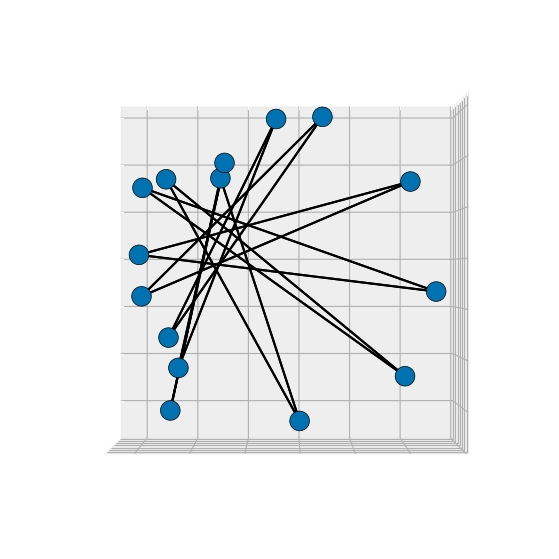

In [91]:
%matplotlib inline
# %matplotlib widget

cycle_v3d_raw_elev = 90
cycle_v3d_raw_azim = 0
cycle_v3d_raw_roll = 0

# Styled plotting constants for this block
cycle_v3d_styled_view = {"elev": cycle_v3d_raw_elev, "azim": cycle_v3d_raw_azim, "roll": cycle_v3d_raw_roll}
cycle_v3d_styled_axis_permutation = (0, 1, 2)

plot_stylized_embedding_graph(
    cycle_v3d_reduced_embeddings,
    cycle_v3d_edge_list,
    title="",
    view=cycle_v3d_styled_view,
    root_node_index=cycle_v3d_root_node_index,
    axis_permutation=cycle_v3d_styled_axis_permutation,
    save_path=f"../saved_plots/regularization/{cycle_v3d_context.args.graph_type}_{cycle_v3d_context.args.model_architecture_label}_embedding_graph_geometric_dropout.pdf",
    save_context=cycle_v3d_context,
);


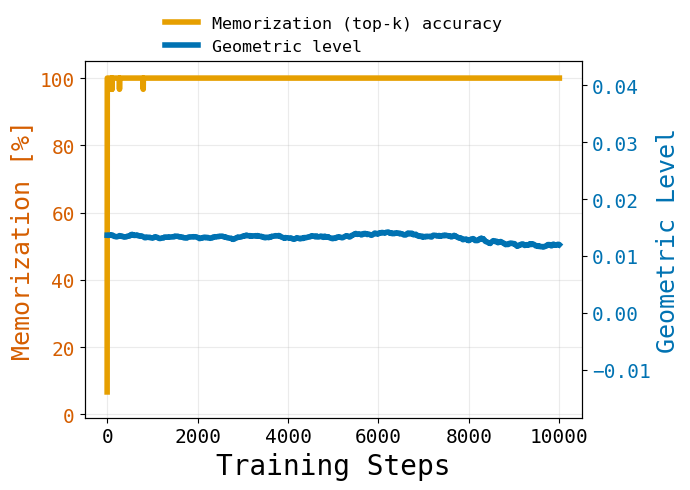

In [92]:
# Line-plot constants for this block
cycle_v3d_line_plot_title = ""

cycle_v3d_curve_steps, cycle_v3d_curve_associative, cycle_v3d_curve_geometric = compute_associative_geometric_curves(
    cycle_v3d_embedding_history,
    cycle_v3d_topk_recovery_history,
    cycle_v3d_edge_list,
)

plot_associative_vs_geometric_curves(
    steps=cycle_v3d_curve_steps,
    associative_scores=cycle_v3d_curve_associative,
    geometric_scores=cycle_v3d_curve_geometric,
    title=cycle_v3d_line_plot_title,
    save_path=f"../saved_plots/regularization/{cycle_v3d_context.args.graph_type}_{cycle_v3d_context.args.model_architecture_label}_associative_geometric_curves_geometric_dropout.pdf",
    save_context=cycle_v3d_context,
);


### Node-Node Embedding Cosine Similarity Heatmap vs Adjacency Matrix

cycle heatmap epoch: 9999
cycle heatmap order rows:
0 1 2 3
4 5 6 7
8 9 10 11
12 13 14


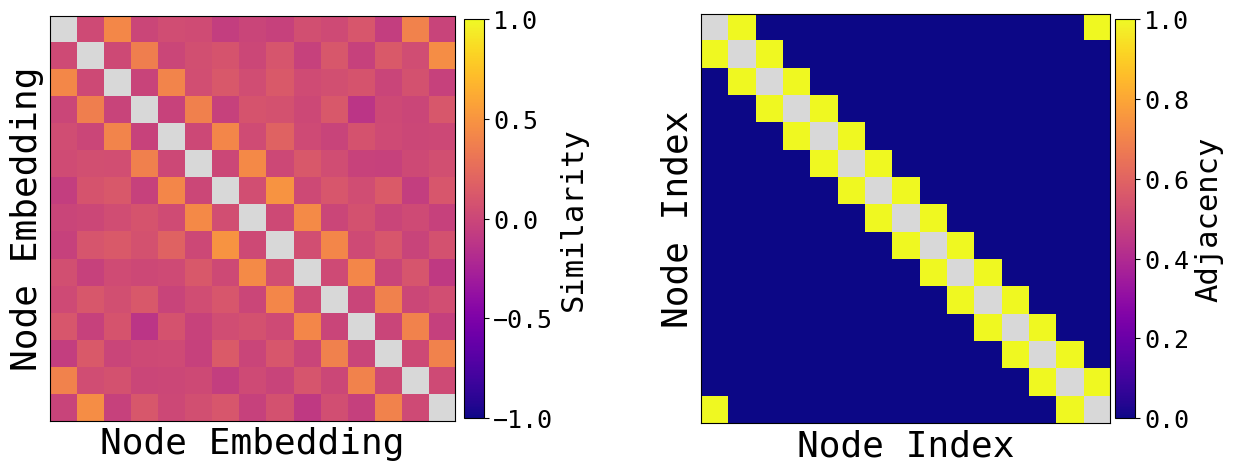

In [93]:
# Heatmap constants for this block
cycle_v3d_heatmap_graph_type = cycle_v3d_context.args.graph_type
cycle_v3d_heatmap_epoch = -1
cycle_v3d_heatmap_cmap_name = "plasma"
cycle_v3d_heatmap_wspace = 0.5

cycle_v3d_heatmap_embeddings, cycle_v3d_heatmap_resolved_epoch = select_embedding_snapshot(
    embedding_history=cycle_v3d_embedding_history,
    fallback_embeddings=cycle_v3d_node_embeddings,
    requested_step=cycle_v3d_heatmap_epoch,
)
print("cycle heatmap epoch:", cycle_v3d_heatmap_resolved_epoch)
cycle_v3d_heatmap_order = list(range(cycle_v3d_heatmap_embeddings.shape[0]))
print("cycle heatmap order rows:")
for row_start in range(0, len(cycle_v3d_heatmap_order), 4):
    row = cycle_v3d_heatmap_order[row_start:row_start + 4]
    print(" ".join(str(node_id) for node_id in row))

plot_ordered_heatmaps(
    embeddings=cycle_v3d_heatmap_embeddings,
    edge_list=cycle_v3d_edge_list,
    graph_type=cycle_v3d_heatmap_graph_type,
    root_node_index=cycle_v3d_root_node_index,
    custom_order=cycle_v3d_heatmap_order,
    cmap_name=cycle_v3d_heatmap_cmap_name,
    wspace=cycle_v3d_heatmap_wspace,
    save_path=f"../saved_plots/regularization/{cycle_v3d_context.args.graph_type}_{cycle_v3d_context.args.model_architecture_label}_embedding_heatmap_geometric_dropout.pdf",
    save_context=cycle_v3d_context,
);


### Skewed Low-Rank Spectral Bias


In [94]:
# Laplacian geometry constants for this block
cycle_v3d_laplacian_axis_indices = (-2, -3, -4)
cycle_v3d_spectral_state = build_graph_spectral_state(
    edge_list=cycle_v3d_edge_list,
    node_count=cycle_v3d_node_embeddings.shape[0],
)

cycle v5 normalized eigenvalues:
 [ 1.     1.     0.732  0.732  0.338  0.338 -0.114 -0.114 -0.547 -0.547
 -0.886 -0.886 -1.071 -1.071]
Tiny cycle (V5) | edge_margin_original: 24.021139
Tiny cycle (V5) | edge_margin_skewed: 9.032664
Tiny cycle (V5) | edge_top1_accuracy_skewed: 100.00%


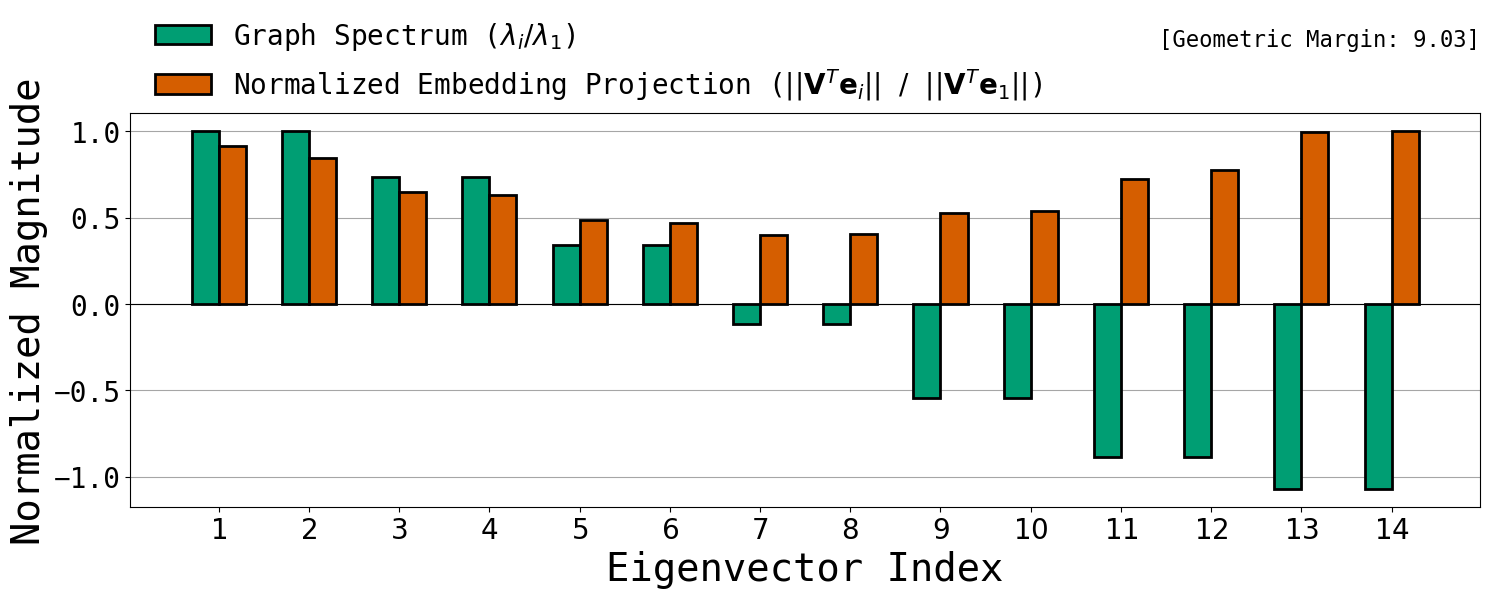

In [95]:
# Spectral-bias constants for this block
cycle_v3d_spectral_drop_top_eigenvector = True
cycle_v3d_spectral_reorder_prefix = None
cycle_v3d_spectral_cutoff = None
cycle_v3d_spectral_figsize = (15.0, 6.0)
cycle_v3d_spectral_legend_anchor = (0.0, 1.3)

cycle_v3d_norm_eigenvalues, cycle_v3d_norm_projections = compute_spectral_bias_from_state(
    embeddings=cycle_v3d_node_embeddings,
    spectral_state=cycle_v3d_spectral_state,
    drop_top_eigenvector=cycle_v3d_spectral_drop_top_eigenvector,
    reorder_prefix=cycle_v3d_spectral_reorder_prefix,
)

print("cycle v5 normalized eigenvalues:\n", cycle_v3d_norm_eigenvalues.round(3))

# Compute margin and accuracy
cycle_v3d_margin_original, cycle_v3d_margin_geometric, cycle_v3d_accuracy_skewed = compute_margin_and_accuracy(
    cycle_v3d_context.model,
    cycle_v3d_edge_list,
    label="Tiny cycle (V5)",
)

plot_spectral_bias(
    norm_eigenvalues=cycle_v3d_norm_eigenvalues,
    norm_projections=cycle_v3d_norm_projections,
    title=f"[Geometric Margin: {cycle_v3d_margin_geometric:.2f}]",
    cutoff=cycle_v3d_spectral_cutoff,
    figsize=cycle_v3d_spectral_figsize,
    ylabel_fontsize=28,
    xlabel_fontsize=28,
    tick_fontsize=20,
    legend_fontsize=20,
    legend_anchor=cycle_v3d_spectral_legend_anchor,
    save=True,
    filename=f"../saved_plots/regularization/{cycle_v3d_context.args.graph_type}_{cycle_v3d_context.args.model_architecture_label}_eigen_projection_geometric_dropout.pdf",
    save_context=cycle_v3d_context,
);